# **Tweet Sentiment Analysis with CNNs**

### **Assignment 5a - Natural Language Processing - MSc. Computer Science, AUE[2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

> Electra Papadopoulou, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> elec.papadopoulou@aueb.gr

> Leonidas Kontogiannis, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> leo.kontogiannis@aueb.gr

## **Text Classification with CNNs**

In [ ]:
%pip install matplotlib seaborn nltk scikit-learn gensim numpy torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.9 MB/s eta 0:00:00


## **Imports**

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
os.environ["KAGGLE_USERNAME"] = "" #add your own username
os.environ["KAGGLE_KEY"] = "" # add your own key

In [ ]:
!pip install -q kaggle
DATA_DIR = "/content/data"
!mkdir -p $DATA_DIR

!kaggle competitions download -c twitter-sentiment-analysis2 -p $DATA_DIR --force
!unzip -qo "$DATA_DIR/twitter-sentiment-analysis2.zip" -d $DATA_DIR

!ls -lh $DATA_DIR


  0% 0.00/14.6M [00:00<?, ?B/s]
100% 14.6M/14.6M [00:00<00:00, 1.56GB/s]
total 48M
-rw-r--r-- 1 root root  25M Nov 28  2019 test.csv
-rw-r--r-- 1 root root 8.3M Nov 28  2019 train.csv
-rw-r--r-- 1 root root  15M Nov 28  2019 twitter-sentiment-analysis2.zip


In [ ]:
try:
    df = pd.read_csv("/content/data/train.csv")
except UnicodeDecodeError:
    df = pd.read_csv("/content/data/train.csv", encoding="ISO-8859-1")

print("Loaded CSV successfully.")
print(df.shape)
df.head()

Loaded CSV successfully.
(99989, 3)


,ItemID,Sentiment,SentimentText
0,1,0,is so sad for my APL frie...
1,2,0,I missed the New Moon trail...
2,3,1,omg its already 7:30 :O
3,4,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,i think mi bf is cheating on me!!! ...


In [ ]:
# Display basic info
print("Full dataset shape:", df.shape)
print(df['Sentiment'].value_counts())

Full dataset shape: (99989, 3)
Sentiment
1    56457
0    43532
Name: count, dtype: int64


### **Exploring the Dataset**

In [ ]:
x, y = df['SentimentText'], df['Sentiment']
print(len(x))
print(len(y))

99989
99989


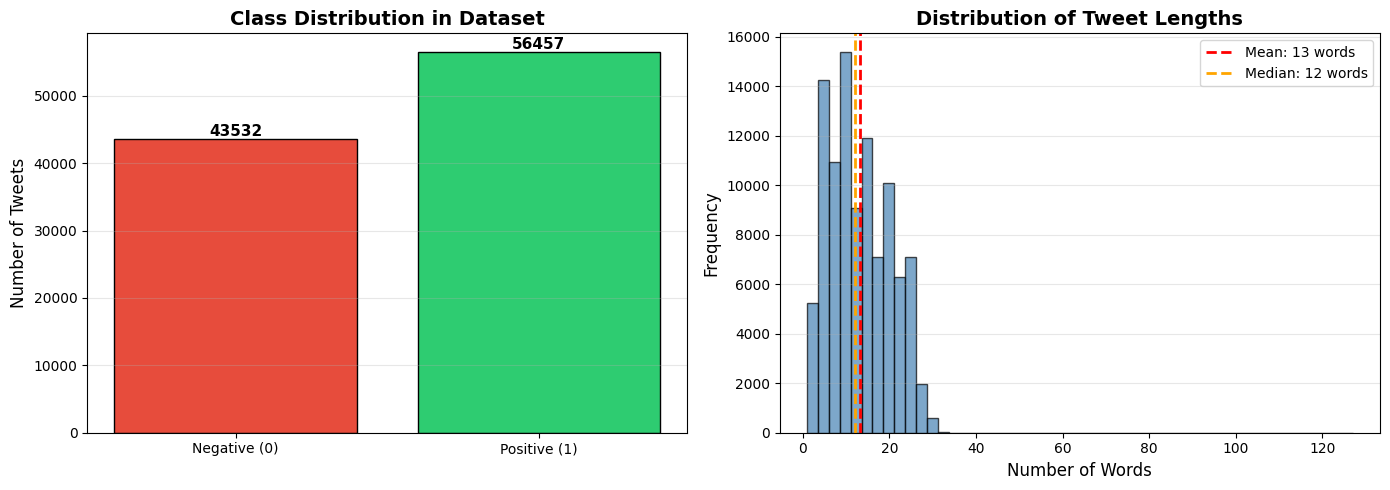

DATASET SUMMARY
Total tweets: 99989
Negative tweets: 43532 (43.5%)
Positive tweets: 56457 (56.5%)

Review Length Statistics:
  Min length: 1 words
  Max length: 127 words
  Mean length: 13.3 words
  Median length: 12.0 words
  Std deviation: 7.0 words


In [ ]:
import matplotlib.pyplot as plt

# Plot 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = np.bincount(y)
axes[0].bar(['Negative (0)', 'Positive (1)'], class_counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
# Add count labels on bars
for i, count in enumerate(class_counts):
    axes[0].text(i, count + 20, str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Tweet Length Distribution
tweet_lengths = [len(str(tweet).split()) for tweet in x]
axes[1].hist(tweet_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(tweet_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(tweet_lengths):.0f} words')
axes[1].axvline(np.median(tweet_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(tweet_lengths):.0f} words')
axes[1].set_xlabel('Number of Words', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Tweet Lengths', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total tweets: {len(x)}")
print(f"Negative tweets: {class_counts[0]} ({class_counts[0]/len(x)*100:.1f}%)")
print(f"Positive tweets: {class_counts[1]} ({class_counts[1]/len(x)*100:.1f}%)")
print(f"\nReview Length Statistics:")
print(f"  Min length: {min(tweet_lengths)} words")
print(f"  Max length: {max(tweet_lengths)} words")
print(f"  Mean length: {np.mean(tweet_lengths):.1f} words")
print(f"  Median length: {np.median(tweet_lengths):.1f} words")
print(f"  Std deviation: {np.std(tweet_lengths):.1f} words")
print("="*60)

###  **Preprocess dataset**

In [ ]:
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 142.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
import re
from tqdm import tqdm

# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["ner","parser"])
# disabling parser and ner may speed up processing since you only need POS + lemma

docs = []
symbol_word_pattern = re.compile(r'\s*[\@\#\&][^\s]+')
html_entity_pattern = re.compile(r'&[a-z]+;')
url_pattern = re.compile(r'https?://\S+|www\.\S+')


for doc_text in tqdm(x):
    # Remove symbol prefix words
    doc_clean = symbol_word_pattern.sub(' ', doc_text)
    # Remove HTML entities
    doc_clean = html_entity_pattern.sub(' ', doc_clean)
    #Remove URLs
    doc_clean = url_pattern.sub(' ', doc_clean)
    # Remove non-word characters (punctuation etc)
    # doc_clean = re.sub(r'\W', ' ', str(doc_clean))
    # Remove single characters (optional)
    #doc_clean = re.sub(r'\s+[a-zA-Z]\s+', ' ', doc_clean)
    # Collapse multiple spaces
    doc_clean = re.sub(r'\s+', ' ', doc_clean, flags=re.I)
    # Lowercase
    doc_clean = doc_clean.lower().strip()

    # Process with spaCy
    doc = nlp(doc_clean)
    tokens = []
    for token in doc:
        tokens.append(token.lemma_)
    # Reconstruct document string
    docs.append(" ".join(tokens))

print("\nOriginal tweet text:\n{}".format(x[0]))
print("\nFiltered tweet text:\n{}".format(docs[0]))
print("\nLabel:\n", y[0])

100%|██████████| 99989/99989 [04:56<00:00, 337.77it/s]


Original tweet text:
                     is so sad for my APL friend.............

Filtered tweet text:
be so sad for my apl friend .............

Label:
 0


In [ ]:
import random

for i in range(10):
    idx = random.randint(0, len(x) - 1)
    print(f"\n===== Sample {i+1} (index {idx}) =====")
    print("\nOriginal tweet text:\n{}".format(x[idx]))
    print("\nFiltered tweet text:\n{}".format(docs[idx]))
    print("\nLabel:\n{}".format(y[idx]))



===== Sample 1 (index 54073) =====

Original tweet text:
@bacon_grease I wish I could go! I love mermaid parades  Looks like I wont be back in NY till Sept. but thx for the bag offer

Filtered tweet text:
I wish I could go ! I love mermaid parade look like I will not be back in ny till sept . but thx for the bag offer

Label:
0

===== Sample 2 (index 15936) =====

Original tweet text:
:: reconnected with the love of my life today and it was amazing and wonderful and healing. Thank you my sweet. 

Filtered tweet text:
: : reconnecte with the love of my life today and it be amazing and wonderful and healing . thank you my sweet .

Label:
1

===== Sample 3 (index 85751) =====

Original tweet text:
@auditiondanny We dig what you write! It's weird that we can follow you, a rockstar, with regular updates :S  Have an awesome day  xoxo

Filtered tweet text:
we dig what you write ! it be weird that we can follow you , a rockstar , with regular update : s have an awesome day xoxo

Label:
1

===

### **Split dataset into train (70%) , test (15%) and dev (15%)**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (70%) and temp (30%)
x_train, x_temp, y_train, y_temp = train_test_split(
    docs,
    y,
    test_size=0.30,
    stratify=y,          # preserve class proportions
    random_state=2025
)

# Split temp (30%) into dev (15%) and test (15%)
x_dev, x_test, y_dev, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,      # 50% of 30% = 15%
    stratify=y_temp,
    random_state=2025
)

# Confirm split sizes
print(f"Train: {len(x_train)}  Dev: {len(x_dev)}  Test: {len(x_test)}")

# Verify label balance
for name, labels in [("Train", y_train), ("Dev", y_dev), ("Test", y_test)]:
    print(f"\n{name} distribution:")
    print(pd.Series(labels).value_counts(normalize=True).round(3))


Train: 69992  Dev: 14998  Test: 14999

Train distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Dev distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Test distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64


## **From Exercise 2: Feature extraction (TF-IDF n-gram features)**



In this step, we convert the preprocessed text data into numerical feature vectors using the **TF-IDF (Term Frequency–Inverse Document Frequency)** representation. TF-IDF measures how important a word is in a document relative to the entire dataset, allowing the model to emphasize informative tokens while discounting common and less meaningful ones.

We apply the `TfidfVectorizer` with the following configuration parameters:

- **n-gram range = (1, 3):** Extracts unigrams, bigrams, and trigrams. This allows the model to capture individual words as well as short phrases that may express sentiment (e.g., *"not good"*, *"very happy"*, *"love this"*).
- **max_features = 30,000:** Limits the vocabulary to the most informative 30,000 terms for computational efficiency.
- **stop_words = 'english':** Removes common non-informative English words (e.g., "the", "and", "is").
- **sublinear_tf = True:** Applies logarithmic scaling to term frequencies, reducing the influence of repeated words.

The resulting TF-IDF vectors are represented as **sparse matrices**, where only non-zero weights are stored to minimize memory usage. After transformation, we inspect:
1. The vocabulary learned by the vectorizer.
2. The dimensionality of the training and test feature matrices.
3. The most influential (highest-weighted) tokens in a sample tweet, which provides interpretability regarding how the model represents text input.

In [ ]:
#Feature extraction (TF-IDF n-gram features)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Use unigram & bi-gram tf*idf features
#vectorizer = TfidfVectorizer(ngram_range = (1, 2),max_features = 5000, sublinear_tf = True)

# Use unigram & bi-gram & tri-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, sublinear_tf = True, stop_words='english')

# Reuse the same TF-IDF vectorizer for all splits
x_train_tfidf = vectorizer.fit_transform(x_train)
x_dev_tfidf   = vectorizer.transform(x_dev)
x_test_tfidf  = vectorizer.transform(x_test)

print([vectorizer.get_feature_names_out()[i] for i in range(1, 50, 5)]) # Shows the learned vocabulary
print(len(vectorizer.get_feature_names_out())) # Number of features == 30000


# Low-dimensional dense representations for MLP
svd_mlp = TruncatedSVD(n_components=500, random_state=2025)
X_train_svd = svd_mlp.fit_transform(x_train_tfidf)
X_dev_svd   = svd_mlp.transform(x_dev_tfidf)
X_test_svd  = svd_mlp.transform(x_test_tfidf)

print("Done Creating SVD")

['000', '00am', '04', '09', '10 30', '10 hour', '10 minute', '10 year old', '100 real photo', '1000th']
30000
Done Creating SVD


In [ ]:
print(vectorizer.get_feature_names_out()[:50])  # show up to 50 features

['00' '000' '000 000' '000 follower' '000 follower bday' '000 people'
 '00am' '00pm' '01' '02' '03' '04' '05' '06' '07' '08' '09' '0_o' '10'
 '10 00' '10 000' '10 30' '10 cat' '10 clock' '10 clock night' '10 day'
 '10 hour' '10 just' '10 million' '10 million dollar' '10 min' '10 minute'
 '10 pm' '10 time' '10 work' '10 year' '10 year old' '100' '100 follower'
 '100 follower day' '100 real' '100 real photo' '100 time' '1000'
 '1000 follower' '1000 time' '1000th' '100th' '100th update' '101']


In [ ]:
print(f'Shape of training data: {x_train_tfidf.shape}')
print(f'Shape of test data: {x_test_tfidf.shape}')

# TFIDF Vectorizer returns Sparse matrix structures --> Saves only the cells which are not zero (be memory efficient), so it can not be printed directly
print(x_test_tfidf.todense()[0, :5000])

Shape of training data: (69992, 30000)
Shape of test data: (14999, 30000)
[[0. 0. 0. ... 0. 0. 0.]]


In [ ]:
doc_index = 0
doc_vector = x_test_tfidf[doc_index].todense()
features = vectorizer.get_feature_names_out()

# Build a DataFrame: each word → its TF-IDF weight in this document
df_doc = pd.DataFrame({
    'Feature': features,
    'TFIDF': doc_vector.tolist()[0]  # convert to 1D list
})

# Show only non-zero entries (words that actually appear in the tweet)
df_nonzero = df_doc[df_doc['TFIDF'] > 0].sort_values(by='TFIDF', ascending=False)

print(f"Number of non-zero features in this document: {len(df_nonzero)}")
print(df_nonzero.head())  # top weighted words


Number of non-zero features in this document: 4
      Feature     TFIDF
24785   spill  0.584581
8808    homie  0.560398
4995       dm  0.432897
27063    true  0.396004


### **Model Training: Baseline and Logistic Regression Classifiers**

In this section, we compare three different classification approaches for tweet sentiment prediction. The aim is to evaluate how different feature representations (TF-IDF vs. Boolean presence) and model assumptions impact classification performance.

#### 1. **Majority Baseline Classifier**
The baseline model predicts the sentiment class that appears most frequently in the training set.  
This provides a **lower-bound performance benchmark**. A good classifier should significantly outperform this baseline.

#### 2. **Logistic Regression with TF-IDF and Character-Level Features**
This model uses a **hybrid feature representation**:
- **Word-level TF-IDF** features (unigrams, bigrams, trigrams)
- **Character-level n-grams** to capture stylistic cues, misspellings, slang, and emojis often found in tweets.

Additionally, we apply:
- **Feature selection using Mutual Information (`SelectKBest`)** to keep the most informative 30,000 features.
- **Class-balanced Logistic Regression** to counteract class imbalance.

This model is expected to capture both semantic and stylistic sentiment signals.

#### 3. **Logistic Regression with Boolean Bag-of-Words Features**
This model uses a **binary CountVectorizer** that records only the *presence or absence* of terms.  
This representation is simpler and may reduce noise, but it ignores term frequency and relative importance of words.

In [ ]:
# === Two Pipelines: Baseline, Logistic Regression (TF-IDF) ===
import time
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1) Majority Baseline (most_frequent)
baseline = Pipeline([
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=2025)),
])

# 2) Logistic Regression (TF-IDF)
vectorizer = FeatureUnion([
    ('word', TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, stop_words='english', sublinear_tf = True)),
    # Character features help with misspellings, slang, and emojis.
    ('char', TfidfVectorizer(analyzer='char', ngram_range=(3,5), max_features=20000))
])

lr_tfidf = Pipeline([
    ('vectorizer', vectorizer),
    ('selector', SelectKBest(mutual_info_classif, k=30000)),
    ('classifier', LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced', C=1))
])

# Quick sanity fits + metrics
def quick_report(name, pipe, x_train, y_train, x_test, y_test):
    t0 = time.time()
    pipe.fit(x_train, y_train)
    dt = time.time() - t0
    ytr = pipe.predict(x_train)
    yte = pipe.predict(x_test)
    print(f"✓ {name} trained in {dt:.3f}s")
    print(f"  Train  Acc: {accuracy_score(y_train, ytr):.4f} | F1: {f1_score(y_train, ytr):.4f}")
    print(f"  Test   Acc: {accuracy_score(y_test, yte): .4f} | F1: {f1_score(y_test, yte): .4f}\n")
    return pipe

print("=== Evaluation ===")
baseline        = quick_report("Baseline",          baseline, x_train, y_train, x_test, y_test)
lr_tfidf        = quick_report("LR (TF-IDF)",       lr_tfidf, x_train, y_train, x_test, y_test)

trained_models = [
    ("Majority Baseline", baseline),
    ("TF-IDF+LR", lr_tfidf)
]


=== Evaluation ===
✓ Baseline trained in 0.002s
  Train  Acc: 0.5646 | F1: 0.7217
  Test   Acc:  0.5646 | F1:  0.7217

✓ LR (TF-IDF) trained in 530.128s
  Train  Acc: 0.8366 | F1: 0.8531
  Test   Acc:  0.7723 | F1:  0.7959



##  **Creating TF-IDF MLP of Exercise 3**

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
class MLP_tf_idf(nn.Module):
    def __init__(self, input_dim=500, hidden_sizes=[256], dropout_prob=0.7):
        super().__init__()

        layers = []
        dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))
            dim = h

        # Final layer: 2 classes (negative/positive)
        layers.append(nn.Linear(dim, 2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

mlp_classifier = MLP_tf_idf()
print(mlp_classifier)

# Count the total number of parameters
total_params = sum(p.numel() for p in mlp_classifier.parameters())
print(f"Total number of parameters: {total_params}")

# Count the number of trainable parameters
trainable_params = sum(p.numel() for p in mlp_classifier.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_params}")

MLP_tf_idf(
  (model): Sequential(
    (0): Linear(in_features=500, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.7, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
Total number of parameters: 128770
Number of trainable parameters: 128770


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_svd, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_dev_tensor = torch.tensor(X_dev_svd, dtype=torch.float32)
y_dev_tensor = torch.tensor(y_dev.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_svd, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # pairs each input vector with its label
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # divides it into mini-batches of 256 and reshuffles data every epoch (shuffle=True)

dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False) #see whats best, shuffle=True or False

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) #see whats best, shuffle=True or False

## **Creating the final MLP model**

In [ ]:
from sklearn.metrics import f1_score

def train_final_model(hidden_sizes, dropout_prob, epochs, lr=0.001):
    model = MLP_tf_idf(hidden_sizes=hidden_sizes, dropout_prob=0.7).to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "dev_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_f1_score": [],
        "val_f1_score": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        all_train_preds = []
        all_train_labels = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds_train = torch.argmax(logits, dim=1)
            all_train_preds.append(preds_train.cpu())
            all_train_labels.append(y_batch.cpu())

        # --- Training metrics ---
        train_preds_tensor = torch.cat(all_train_preds)
        train_labels_tensor = torch.cat(all_train_labels)
        train_acc = (train_preds_tensor == train_labels_tensor).float().mean().item()
        train_f1 = f1_score(train_labels_tensor, train_preds_tensor, average='macro')

        avg_train_loss = running_loss / len(train_loader)

        # --- Validation metrics ---
        model.eval()
        with torch.no_grad():
            dev_logits = model(X_dev_tensor.to(device))
            dev_loss = criterion(dev_logits, y_dev_tensor.to(device)).item()
            dev_preds = torch.argmax(dev_logits, dim=1).cpu()
            val_acc = (dev_preds == y_dev_tensor).float().mean().item()
            val_f1 = f1_score(y_dev, dev_preds, average='macro')

        # --- Append to history ---
        history["train_loss"].append(avg_train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["train_f1_score"].append(train_f1)
        history["val_f1_score"].append(val_f1)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss={avg_train_loss:.4f} | Dev Loss={dev_loss:.4f} | "
              f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | "
              f"Train F1={train_f1:.4f} | Val F1={val_f1:.4f}")

    return model, history



In [ ]:
best_model_mlp, history_mlp = train_final_model(
    hidden_sizes=[512],
    dropout_prob=0.7,
    epochs=26,
    lr=0.001
)

Epoch 1/26 | Train Loss=0.5883 | Dev Loss=0.5525 | Train Acc=0.6743 | Val Acc=0.7098 | Train F1=0.6416 | Val F1=0.6969
Epoch 2/26 | Train Loss=0.5435 | Dev Loss=0.5509 | Train Acc=0.7160 | Val Acc=0.7108 | Train F1=0.7039 | Val F1=0.6966
Epoch 3/26 | Train Loss=0.5395 | Dev Loss=0.5508 | Train Acc=0.7200 | Val Acc=0.7131 | Train F1=0.7077 | Val F1=0.7034
Epoch 4/26 | Train Loss=0.5362 | Dev Loss=0.5498 | Train Acc=0.7206 | Val Acc=0.7110 | Train F1=0.7089 | Val F1=0.6990
Epoch 5/26 | Train Loss=0.5338 | Dev Loss=0.5492 | Train Acc=0.7241 | Val Acc=0.7141 | Train F1=0.7124 | Val F1=0.7036
Epoch 6/26 | Train Loss=0.5303 | Dev Loss=0.5495 | Train Acc=0.7271 | Val Acc=0.7128 | Train F1=0.7157 | Val F1=0.6966
Epoch 7/26 | Train Loss=0.5279 | Dev Loss=0.5506 | Train Acc=0.7280 | Val Acc=0.7146 | Train F1=0.7165 | Val F1=0.7066
Epoch 8/26 | Train Loss=0.5250 | Dev Loss=0.5499 | Train Acc=0.7324 | Val Acc=0.7138 | Train F1=0.7212 | Val F1=0.7003
Epoch 9/26 | Train Loss=0.5218 | Dev Loss=0.5499

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

best_model_mlp.eval()
best_model_mlp.to("cpu")  # move to CPU for sklearn

# Dev predictions
with torch.no_grad():
    dev_logits = best_model_mlp(X_dev_tensor)
    dev_preds = torch.argmax(dev_logits, dim=1)

# Test predictions
with torch.no_grad():
    test_logits = best_model_mlp(X_test_tensor)
    test_preds = torch.argmax(test_logits, dim=1)

print(f"Dev Accuracy:  {accuracy_score(y_dev, dev_preds)*100:.2f}%")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%")

print("\nDev performance:")
print(classification_report(y_dev, dev_preds, target_names=['Negative', 'Positive'], digits=4))

print("\nTest performance:")
print(classification_report(y_test, test_preds, target_names=['Negative', 'Positive'], digits=4))


Dev Accuracy:  71.62%
Test Accuracy: 71.54%

Dev performance:
              precision    recall  f1-score   support

    Negative     0.7070    0.5946    0.6460      6530
    Positive     0.7215    0.8100    0.7632      8468

    accuracy                         0.7162     14998
   macro avg     0.7143    0.7023    0.7046     14998
weighted avg     0.7152    0.7162    0.7122     14998


Test performance:
              precision    recall  f1-score   support

    Negative     0.7079    0.5896    0.6433      6530
    Positive     0.7197    0.8124    0.7632      8469

    accuracy                         0.7154     14999
   macro avg     0.7138    0.7010    0.7033     14999
weighted avg     0.7145    0.7154    0.7110     14999



In [ ]:
best_model_mlp.eval()
best_model_mlp.to("cpu")

# --- Validation accuracy ---
y_pred_val = torch.argmax(best_model_mlp(X_dev_tensor), dim=1)
val_acc = accuracy_score(y_dev, y_pred_val)
print(f'Validation Accuracy: {val_acc*100:.2f}%')

# --- Test accuracy ---
y_pred_test = torch.argmax(best_model_mlp(X_test_tensor), dim=1)
test_acc = accuracy_score(y_test, y_pred_test)
print(f'Test Accuracy: {test_acc*100:.2f}%')


Validation Accuracy: 71.62%
Test Accuracy: 71.54%


## **Data Preprocessing for the RNN and CNN**

### Vocabulary building

In [ ]:
from collections import Counter

def build_vocab(texts, min_freq, max_vocab_size=None):
    # counte every word
    cnt = Counter()
    for doc in texts:
        for tok in doc.split():
            cnt[tok] += 1

    # special tokens
    specials = ["<pad>", "<unk>"]

    # remove infrequent words
    items = [w for w,f in cnt.most_common() if f >= min_freq]

    if max_vocab_size:
        items = items[:max_vocab_size - len(specials)]

    idx2str = specials + items
    str2idx = {w:i for i,w in enumerate(idx2str)}
    return str2idx, idx2str, cnt

# Build on train only
str2idx, idx2str, counter = build_vocab(x_train, min_freq=1, max_vocab_size=50000)
vocab_size = len(idx2str)
print("Vocab size:", vocab_size)
print("Top 20 tokens:", idx2str[2:22])

Vocab size: 39443
Top 20 tokens: ['I', 'be', '!', '.', ',', 'to', 'you', 'the', '?', 'not', 'a', 'it', 'have', 'do', 'and', 'that', '...', 'my', 'for', 'in']


In [ ]:
train_clean_x = []
train_clean_y = []

for text, label in zip(x_train, y_train):
    if text.strip() != "":
        train_clean_x.append(text)
        train_clean_y.append(label)

dev_clean_x = []
dev_clean_y = []

for text, label in zip(x_dev, y_dev):
    if text.strip() != "":
        dev_clean_x.append(text)
        dev_clean_y.append(label)

test_clean_x = []
test_clean_y = []

for text, label in zip(x_test, y_test):
    if text.strip() != "":
        test_clean_x.append(text)
        test_clean_y.append(label)

In [ ]:
tokenized_train = [tweet.split() for tweet in train_clean_x]
#tokenized_dev = [tweet.split() for tweet in x_dev]
#tokenized_text = [tweet.split() for tweet in x_test]

print(tokenized_train[:3])

print("Length:", len(tokenized_train))
print("Empty docs:", sum(1 for d in tokenized_train if len(d) == 0))

[['my', 'bag', 'steal', 'from', 'beneath', 'table', '@', 'pub', 'tonight', '.', 'it', 'have', 'all', 'my', 'stuff', 'in', 'it', '.', 'lot', 'of', 'bit', '.', 'kinda', 'know', 'how', 'u', 'feel', 'bout', 'diary'], ['aww', '.', 'I', 'be', 'glad', 'that', 'he', 'give', 'she', 'a', 'shoutout', '.', 'she', 'go', 'to', 'bed', 'like', '20', 'minute', 'too', 'early', '!', '!', '!', '!'], ['..', 'and', 'of', 'course', '...', 'I', 'have', 'access', 'to', 'my', 'halo', '3', 'mythic', 'map', 'pack', 're', '-', 'download', '..', 'but', 'bad', 'news', '..', 'not', 'the', 'legendary', 'map', 'pack', '...', 'ugh', '..', '600ms', '...']]
Length: 69715
Empty docs: 0


### Create word embeddings using the train dataset

In [ ]:
!pip install gensim

In [ ]:
from gensim.models import Word2Vec

EMB_DIM = 100

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=EMB_DIM,
    window=5,
    min_count=1,
    workers=-1,
    sg=1,          # 1 = skip-gram (better for rare/informal words), 0 = CBOW
    epochs=10
)

print("Word2Vec vocab size:", len(w2v_model.wv)) # # number of tokens in vocabulary
print(w2v_model.wv['happy'])     # try an example lookup

Word2Vec vocab size: 39441
[-9.8972367e-03 -9.2722382e-03  5.8333920e-03  9.8299198e-03
 -7.1276496e-03  3.9819549e-03  8.6080553e-03 -6.2030577e-03
 -4.2331610e-03  6.2131546e-03 -3.8250624e-03  6.7299865e-03
 -7.0787347e-03 -2.2851503e-03  5.2328170e-03  6.2291883e-03
  2.9586744e-03  5.3230167e-04  5.2966760e-03  7.2170151e-03
  7.3386384e-03  8.1931995e-03  3.8847995e-03 -6.7879353e-03
  6.9916607e-03 -1.2386394e-03 -2.2181976e-03  8.8652829e-03
  6.8575335e-03 -4.1045318e-03  4.6568131e-03 -6.9662845e-03
 -6.7587672e-03  7.4287462e-03 -7.9577806e-04 -9.9229375e-03
  6.7418446e-03  7.9033338e-03  2.7702164e-03 -6.4465418e-03
  1.4814138e-05 -1.7609894e-03 -1.3711405e-03  7.2757495e-03
 -5.1005743e-03 -9.8485379e-03  4.5062886e-03  5.7537924e-03
  5.3813052e-03 -8.0962693e-03  8.4944163e-03  2.8093886e-03
 -8.5122586e-04 -2.4791933e-03 -2.1195328e-03 -1.4243925e-03
  4.3527698e-03  7.3043583e-03  1.2716174e-04  2.5126755e-03
  5.5437803e-04 -6.1966274e-03  3.7118089e-03 -6.5833880e-

In [ ]:
import numpy as np

embedding_matrix = np.zeros((vocab_size, EMB_DIM), dtype=np.float32)

for idx, word in enumerate(idx2str):
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMB_DIM,))

embedding_layer = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=EMB_DIM,
    padding_idx=str2idx["<pad>"]
)

# load our custom matrix
embedding_layer.weight.data.copy_(torch.from_numpy(embedding_matrix))

embedding_layer.weight.requires_grad = True   # fine-tune

def tweet_to_vec(tokens, w2v_model, embedding_dim=EMB_DIM):
    vectors = []
    for token in tokens:
        if token in w2v_model.wv:
            vectors.append(w2v_model.wv[token])
    if len(vectors) == 0:
        # return zero vector if no tokens matched
        return np.zeros(embedding_dim, dtype=np.float32)
    return np.mean(vectors, axis=0)

### PyTorch Dataset + DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

class TweetsSeqDataset(Dataset):
    def __init__(self, texts, labels, str2idx):
        """
        texts: list of cleaned strings (space-separated tokens)
        labels: list/array of ints (0..C-1)
        str2idx: dict token->index, with "<pad>" and "<unk>"
        """
        self.texts = texts
        self.labels = np.array(labels)
        self.str2idx = str2idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.texts[idx].split()
        indices = [self.str2idx.get(t, self.str2idx["<unk>"]) for t in tokens]
        if len(indices) == 0:
            # avoid zero-length sequences (replace with pad token index so collate handles it)
            indices = [self.str2idx["<pad>"]]
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def collate_batch_pad(batch):
    """
    batch: list of (indices_tensor, label_tensor)
    returns:
      tokens_padded: (B, T) LongTensor
      lengths: (B,) LongTensor
      labels: (B,) LongTensor
    """
    tokens = [item[0] for item in batch]
    labels = torch.stack([item[1] for item in batch])
    lengths = torch.tensor([t.shape[0] for t in tokens], dtype=torch.long)
    tokens_padded = pad_sequence(tokens, batch_first=True, padding_value=str2idx["<pad>"])
    return tokens_padded, lengths, labels

In [ ]:
BATCH_SIZE = 256

train_ds = TweetsSeqDataset(train_clean_x, train_clean_y, str2idx)
dev_ds   = TweetsSeqDataset(dev_clean_x,   dev_clean_y,   str2idx)
test_ds  = TweetsSeqDataset(test_clean_x,  test_clean_y,  str2idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch_pad)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch_pad)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch_pad)

print("Samples:", len(train_ds), len(dev_ds), len(test_ds))

Samples: 69715 14929 14932


In [ ]:
import gc

# Free RAM
del w2v_model
gc.collect()

30

## **Creating the RNN Model of Exercise 4**

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim, attn_hidden_dim=None):
        """
        hidden_dim: dimension of BiRNN hidden states (per direction concatenated -> 2*hid)
        attn_hidden_dim: if provided, use a single hidden layer MLP for attention scores
        """
        super().__init__()
        if attn_hidden_dim is None:
            # single linear score: score = v^T tanh(W h + b)
            self.w = nn.Linear(hidden_dim, hidden_dim, bias=True)
            self.v = nn.Linear(hidden_dim, 1, bias=False)
            self.use_mlp = False
        else:
            # small MLP: h -> ReLU -> score
            self.mlp = nn.Sequential(
                nn.Linear(hidden_dim, attn_hidden_dim),
                nn.ReLU(),
                nn.Linear(attn_hidden_dim, 1)
            )
            self.use_mlp = True

    def forward(self, H, mask=None):
        """
        H: (B, T, hidden_dim)
        mask: (B, T) with 1 for token, 0 for pad (optional)
        Returns: context (B, hidden_dim) and attn_weights (B, T)
        """
        if self.use_mlp:
            scores = self.mlp(H).squeeze(-1)  # (B, T)
        else:
            x = torch.tanh(self.w(H))         # (B, T, hidden_dim)
            scores = self.v(x).squeeze(-1)    # (B, T)
        if mask is not None:
            # mask: 1 for valid, 0 for pad -> set pad scores to very negative
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=-1)  # (B, T)
        # compute weighted sum
        attn_weights_unsq = attn_weights.unsqueeze(-1)  # (B, T, 1)
        context = torch.sum(H * attn_weights_unsq, dim=1)  # (B, hidden_dim)
        return context, attn_weights

In [ ]:
class BiLSTMWithAttention(nn.Module):
    def __init__(self, embedding_matrix, pad_idx, hidden_size=256, num_layers=2,
                 dropout=0.3, bidirectional=True, rnn_type='lstm', attn_hidden_dim=None,
                 fine_tune_embeddings=True, num_classes=2, emb_dropout=0.2):
        """
        embedding_matrix: numpy array [vocab_size, emb_dim]
        pad_idx: index used for padding (so embedding_layer padding_idx)
        hidden_size: LSTM hidden size per direction
        num_layers: stacked RNN layers
        bidirectional: True
        rnn_type: 'lstm' or 'gru'  (you requested LSTM)
        attn_hidden_dim: if None -> single dense attention as in slides; else small MLP with this hidden dim
        fine_tune_embeddings: whether to allow embedding updates
        num_classes: number of output classes
        """
        super().__init__()
        emb_weights = torch.tensor(embedding_matrix, dtype=torch.float)
        vocab_size, emb_dim = emb_weights.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(emb_weights)
        self.embedding.weight.requires_grad = fine_tune_embeddings

        self.emb_dropout = nn.Dropout(emb_dropout) if emb_dropout and emb_dropout>0 else nn.Identity()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        num_directions = 2 if bidirectional else 1

        if rnn_type.lower() == 'lstm':
            self.rnn = nn.LSTM(
                input_size=emb_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers>1 else 0.0,
                bidirectional=bidirectional
            )
        else:
            self.rnn = nn.GRU(
                input_size=emb_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers>1 else 0.0,
                bidirectional=bidirectional
            )

        # attention sees concatenated hidden states size = hidden_size * num_directions
        attn_in_dim = hidden_size * num_directions
        self.attention = SelfAttention(attn_in_dim, attn_hidden_dim)

        # classifier head
        self.classifier = nn.Sequential(
            nn.Linear(attn_in_dim, attn_in_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(attn_in_dim//2, num_classes)
        )

    def forward(self, tokens, lengths):
        """
        tokens: (B, T) LongTensor
        lengths: (B,) LongTensor
        returns logits (B, num_classes), attn_weights (B, T)
        """
        mask = (tokens != self.embedding.padding_idx).long().to(tokens.device)  # (B, T)
        emb = self.embedding(tokens)  # (B, T, E)
        emb = self.emb_dropout(emb)

        # pack
        lengths_cpu = lengths.cpu()
        packed = pack_padded_sequence(emb, lengths_cpu, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.rnn(packed)  # packed output
        out, _ = pad_packed_sequence(packed_out, batch_first=True)  # (B, T, num_directions*hidden)

        # out may be shorter in T than tokens due to pack/pad; ensure mask shape matches out.shape[1]
        if out.shape[1] != mask.shape[1]:
            # crop or pad mask appropriately
            if out.shape[1] < mask.shape[1]:
                mask = mask[:, :out.shape[1]]
            else:
                pad_extra = out.shape[1] - mask.shape[1]
                mask = torch.cat([mask, torch.zeros(mask.size(0), pad_extra, device=mask.device, dtype=mask.dtype)], dim=1)

        context, attn_weights = self.attention(out, mask=mask)  # context: (B, attn_in_dim)
        logits = self.classifier(context)  # (B, num_classes)
        return logits, attn_weights

## Creating the CNN Model

In [ ]:
class CNNBlock(nn.Module):
    def __init__(self, emb_dim, kernel_sizes, out_channels):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=emb_dim,
                out_channels=out_channels,
                kernel_size=k,
                padding=k-1   # ensures >= T output
            )
            for k in kernel_sizes
        ])
        self.act = nn.ReLU()
        self.project = nn.Conv1d(
            out_channels * len(kernel_sizes),
            emb_dim,
            kernel_size=1
        )
        self.norm = nn.LayerNorm(emb_dim)

    def forward(self, x):
        # x: (B, E, T)
        T = x.size(2)
        feats = []
        for conv in self.convs:
            out = self.act(conv(x))     # (B, C, T + padding)
            out = out[:, :, :T]         # trim to exact length
            feats.append(out)
        cat = torch.cat(feats, dim=1)   # all T match now
        proj = self.project(cat)
        proj = self.norm(proj.transpose(1,2)).transpose(1,2)
        return proj + x    # residual


In [ ]:
class StackedCNNClassifier(nn.Module):
    """
    Stacked CNN with n-gram filters, residual connections, and global max-pooling.
    - embedding_matrix: numpy array (vocab, emb_dim)
    - pad_idx: index used for padding
    """
    def __init__(self, embedding_matrix, pad_idx,
                 num_blocks=3,
                 kernel_sizes=(2,3,4),
                 out_channels_per_filter=128,
                 dropout=0.3,
                 fine_tune_embeddings=True,
                 num_classes=2,
                 emb_dropout=0.4):
        super().__init__()
        emb_weights = torch.tensor(embedding_matrix, dtype=torch.float32)
        vocab_size, emb_dim = emb_weights.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(emb_weights)
        self.embedding.weight.requires_grad = fine_tune_embeddings

        self.emb_dropout = nn.Dropout(emb_dropout)

        # stack of ConvBlocks, each block keeps channel dim = emb_dim (we project back to emb_dim)
        blocks = []
        for _ in range(num_blocks):
            block = CNNBlock(emb_dim=emb_dim, out_channels=out_channels_per_filter, kernel_sizes=kernel_sizes)
            blocks.append(block)
        self.blocks = nn.ModuleList(blocks)

        # final global max-pool over time dimension -> (B, emb_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, num_classes)
        )

    def forward(self, tokens, lengths=None):
        """
        tokens: (B, T) long
        lengths: optional (not used by convs, but kept for compatibility)
        returns: logits (B, num_classes), pooled_feat (B, emb_dim)
        """
        mask = (tokens != self.embedding.padding_idx).long().to(tokens.device)  # (B, T)
        emb = self.embedding(tokens)    # (B, T, E)
        emb = self.emb_dropout(emb)
        # conv expects (B, E, T)
        x = emb.transpose(1, 2)        # (B, E, T)
        for block in self.blocks:
            x = block(x)               # (B, E, T) preserved
        # mask out padding positions before pooling: set padded positions to very small value
        if mask is not None:
            # mask: 1 for valid, 0 for pad -> we expand to channel dims and set padding to -inf
            mask_f = mask.unsqueeze(1).float()  # (B,1,T)
            neg_inf = -1e9
            x = x * mask_f + (1.0 - mask_f) * neg_inf
        # global max pool over time
        pooled = torch.max(x, dim=2)[0]  # (B, E)
        feats = self.dropout(pooled)
        logits = self.classifier(feats)
        return logits, pooled

## Utilities

In [ ]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    classification_report,
    average_precision_score
)
import numpy as np
import torch

def compute_metrics_all(y_true, y_pred, y_prob, labels_list):
    """
    Computes:
    - per-class precision, recall, F1, AUC-PR
    - macro averages
    - overall accuracy
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------- overall accuracy ----------
    overall_acc = accuracy_score(y_true, y_pred)

    # ---------- per-class precision, recall, f1 ----------
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_list, zero_division=0
    )

    # ---------- per-class AUC-PR ----------
    auc_pr = []
    for cls in labels_list:
        # binarize true labels
        y_true_bin = (y_true == cls).astype(int)
        y_prob_cls = y_prob[:, cls]

        try:
            auc = average_precision_score(y_true_bin, y_prob_cls)
        except ValueError:
            auc = 0.0

        auc_pr.append(auc)

    # ---------- macro metrics ----------
    macro_prec = np.mean(prec)
    macro_rec  = np.mean(rec)
    macro_f1   = np.mean(f1)
    macro_auc  = np.mean(auc_pr)

    # ---------- build dictionary ----------
    results = {
        "overall": {
            "accuracy": overall_acc
        },
        "per_class": {
            "precision": prec.tolist(),
            "recall": rec.tolist(),
            "f1": f1.tolist(),
            "auc_pr": auc_pr,
            "support": support.tolist()
        },
        "macro": {
            "precision": macro_prec,
            "recall": macro_rec,
            "f1": macro_f1,
            "auc_pr": macro_auc
        }
    }

    return results


In [ ]:
def evaluate_model(model, loader, labels_list):
    model.eval()
    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for tokens, lengths, labels in loader:
            tokens  = tokens.to(device)
            lengths = lengths.to(device)
            labels  = labels.to(device)

            logits, _ = model(tokens, lengths)
            probs = torch.softmax(logits, dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
            all_prob.extend(probs.cpu().numpy())

    all_prob = np.array(all_prob)

    return compute_metrics_all(
        y_true=all_true,
        y_pred=all_pred,
        y_prob=all_prob,
        labels_list=labels_list
    )


### Training of the RNN and CNN

In [ ]:
import copy
import time

def train_one_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0.0
    n = 0
    for tokens, lengths, labels in tqdm(loader, desc="Train batches", leave=False):
        tokens = tokens.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits, _ = model(tokens, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        # gradient clipping
        if clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)
    return total_loss / n

def run_training(
    model,
    train_loader,
    dev_loader,
    labels_list,
    lr=1e-3,
    epochs=20,
    patience=5,
    weight_decay=1e-5,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    # store best model parameters in memory
    best_model_state = None
    best_dev_f1 = -1.0

    best_epoch = -1

    history = {
        "train_loss": [],
        "dev_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_f1": [],
        "val_f1": []
    }

    no_improve = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # -------------------------
        # TRAIN ONE EPOCH
        # -------------------------
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)

        # -------------------------
        # DEV LOSS
        # -------------------------
        model.eval()
        total_dev_loss = 0
        n_dev = 0
        with torch.no_grad():
            for tokens, lengths, labels in dev_loader:
                tokens = tokens.to(device)
                lengths = lengths.to(device)
                labels = labels.to(device)

                logits, _ = model(tokens, lengths)
                loss = criterion(logits, labels)

                total_dev_loss += loss.item() * labels.size(0)
                n_dev += labels.size(0)

        dev_loss = total_dev_loss / n_dev

        # -------------------------
        # METRICS (train + dev)
        # -------------------------
        train_metrics = evaluate_model(model, train_loader, labels_list)
        dev_metrics = evaluate_model(model, dev_loader, labels_list)

        train_acc = train_metrics["overall"]["accuracy"]
        dev_acc   = dev_metrics["overall"]["accuracy"]

        train_f1 = train_metrics["macro"]["f1"]
        dev_f1   = dev_metrics["macro"]["f1"]

        # -------------------------
        # STORE HISTORY
        # -------------------------
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(dev_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(dev_f1)

        took = time.time() - t0
        print(
            f"Epoch {epoch:02d} | "
            f"TrainLoss={train_loss:.4f} DevLoss={dev_loss:.4f} | "
            f"TrainF1={train_f1:.4f} DevF1={dev_f1:.4f} | "
            f"Time={took:.1f}s"
        )

        # -------------------------
        # EARLY STOPPING BASED ON DEV F1
        # -------------------------
        if dev_f1 > best_dev_f1:
            best_dev_f1 = dev_f1
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            print("  -> New best model found!")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping after {patience} epochs without improvement.")
                break

    # -------------------------
    # LOAD BEST MODEL (in-memory)
    # -------------------------
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history, best_dev_f1, best_epoch


## **Hyperparameter Tuning CNN model**

In [ ]:
import random
import itertools
import pprint
import json

random.seed(2025)

search_space = {
    "num_blocks": [2, 3, 4],
    "kernel_sizes": [(2,3), (2,3,4)],
    "out_ch_per_filter": [64, 128, 256],
    "dropout": [0.2, 0.4, 0.6],
    "lr": [0.01, 0.001, 0.0001]
}

keys, values = zip(*search_space.items())
grid_list = [dict(zip(keys, v)) for v in itertools.product(*values)]
print("Total trials:", len(grid_list))

seen_configs = set()

def sample_config():
    while True:
        config = {
          "num_blocks": random.choice(search_space["num_blocks"]),
          "kernel_sizes": random.choice(search_space["kernel_sizes"]),
          "out_ch_per_filter": random.choice(search_space["out_ch_per_filter"]),
          "dropout": random.choice(search_space["dropout"]),
          "lr": random.choice(search_space["lr"])
        }

        # Convert config to an immutable representation
        key = json.dumps(config, sort_keys=True)

        if key not in seen_configs:
            seen_configs.add(key)
            return config

In [ ]:
import random
import copy

random.seed(SEED)

MAX_EPOCHS = 10
PATIENCE = 5

def random_search(
    train_loader,
    dev_loader,
    labels_list,
    num_samples=10
):

    best_model = None
    best_hist = None
    best_hparams = None
    best_score = -1.0

    for i in range(num_samples):
        print(f"\n===== Random Search Trial {i+1}/{num_samples} =====")

        # Sample hyperparameters
        hparams = sample_config()
        print("Hyperparameters:", hparams)

        model = StackedCNNClassifier(
            embedding_matrix=embedding_matrix,
            pad_idx=str2idx["<pad>"],
            num_blocks=hparams["num_blocks"],
            kernel_sizes=hparams["kernel_sizes"],
            out_channels_per_filter=hparams["out_ch_per_filter"],
            dropout=hparams["dropout"],
            fine_tune_embeddings=True,
            num_classes=2
        )

        trained_model, history, dev_score, best_epoch = run_training(
            model, train_loader, dev_loader, labels_list,
            lr=hparams["lr"], epochs=MAX_EPOCHS, patience=PATIENCE
        )

        print(f"Trial score (Macro F1): {dev_score:.4f}")

        if dev_score > best_score:
            best_score = dev_score
            best_model = copy.deepcopy(trained_model)
            best_hist = history
            best_hparams = hparams.copy()

    return best_model, best_hparams, best_hist, best_score

*Note: it takes ~8 hours to run*

In [ ]:
import pprint

best_cnn_model, best_cnn_hparams, best_cnn_history, best_cnn_score = random_search(
    train_loader=train_loader,
    dev_loader=dev_loader,
    labels_list=[0, 1],
    num_samples=10
)


===== Random Search Trial 1/10 =====
Hyperparameters: {'num_blocks': 4, 'kernel_sizes': (2, 3), 'out_ch_per_filter': 256, 'dropout': 0.4, 'lr': 0.01}


Epoch 01 | TrainLoss=0.5873 DevLoss=0.5147 | TrainF1=0.7553 DevF1=0.7281 | Time=625.3s
  -> New best model found!


Epoch 02 | TrainLoss=0.4998 DevLoss=0.4938 | TrainF1=0.8073 DevF1=0.7559 | Time=597.1s
  -> New best model found!


Epoch 03 | TrainLoss=0.4683 DevLoss=0.4814 | TrainF1=0.8291 DevF1=0.7600 | Time=597.4s
  -> New best model found!


Epoch 04 | TrainLoss=0.4410 DevLoss=0.4970 | TrainF1=0.8395 DevF1=0.7608 | Time=602.5s
  -> New best model found!


Epoch 05 | TrainLoss=0.4232 DevLoss=0.4923 | TrainF1=0.8539 DevF1=0.7586 | Time=611.0s


Epoch 06 | TrainLoss=0.4083 DevLoss=0.5533 | TrainF1=0.8492 DevF1=0.7457 | Time=1750.9s


Epoch 07 | TrainLoss=0.3963 DevLoss=0.5164 | TrainF1=0.8696 DevF1=0.7497 | Time=3804.4s


Epoch 08 | TrainLoss=0.3829 DevLoss=0.5542 | TrainF1=0.8726 DevF1=0.7478 | Time=4121.4s


## ReCreate the CNN Model

In [ ]:
# Create best model from the Hyperparameter Tuning
model_cnn = StackedCNNClassifier(
    embedding_matrix=embedding_matrix,
    pad_idx=str2idx["<pad>"],
    num_blocks=2,
    kernel_sizes=(2, 3),
    out_channels_per_filter=64,
    dropout=0.4,
    fine_tune_embeddings=True,
    num_classes=2
)

print(model_cnn)

trained_model_cnn, history_cnn, f1_score_cnn, best_epoch_cnn = run_training(
    model_cnn,
    train_loader,
    dev_loader,
    [0,1],
    lr=0.01,
    epochs=10,
    patience=5
)
print("Trial dev macro F1:", f1_score_cnn)

StackedCNNClassifier(
  (embedding): Embedding(39443, 100, padding_idx=0)
  (emb_dropout): Dropout(p=0.4, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x CNNBlock(
      (convs): ModuleList(
        (0): Conv1d(100, 64, kernel_size=(2,), stride=(1,), padding=(1,))
        (1): Conv1d(100, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      )
      (act): ReLU()
      (project): Conv1d(128, 100, kernel_size=(1,), stride=(1,))
      (norm): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=100, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=50, out_features=2, bias=True)
  )
)


Epoch 01 | TrainLoss=0.5556 DevLoss=0.4970 | TrainF1=0.7824 DevF1=0.7492 | Time=8.3s
  -> New best model found!


Epoch 02 | TrainLoss=0.4787 DevLoss=0.4836 | TrainF1=0.8257 DevF1=0.7622 | Time=6.5s
  -> New best model found!


Epoch 03 | TrainLoss=0.4431 DevLoss=0.4907 | TrainF1=0.8465 DevF1=0.7611 | Time=6.9s


Epoch 04 | TrainLoss=0.4170 DevLoss=0.5117 | TrainF1=0.8477 DevF1=0.7541 | Time=7.1s


Epoch 05 | TrainLoss=0.4007 DevLoss=0.5424 | TrainF1=0.8666 DevF1=0.7570 | Time=6.5s


Epoch 06 | TrainLoss=0.3837 DevLoss=0.5400 | TrainF1=0.8778 DevF1=0.7571 | Time=7.2s


Epoch 07 | TrainLoss=0.3711 DevLoss=0.5787 | TrainF1=0.8862 DevF1=0.7513 | Time=6.5s
Early stopping after 5 epochs without improvement.
Trial dev macro F1: 0.7621604163646617


## **Curves**

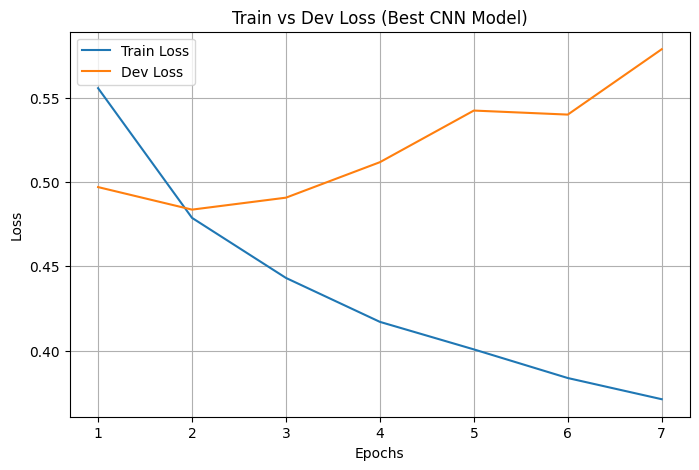

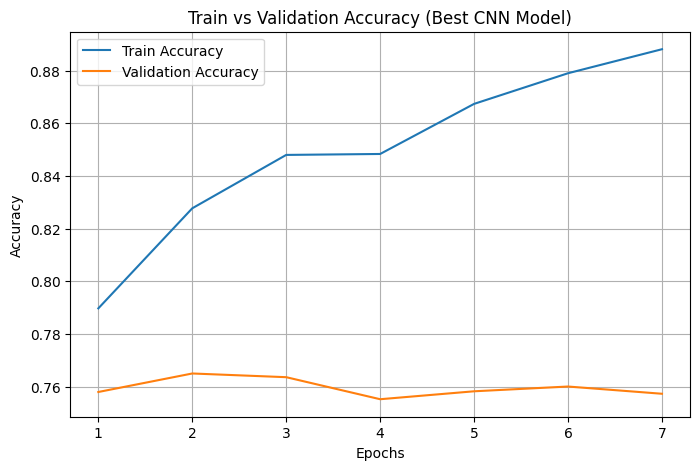

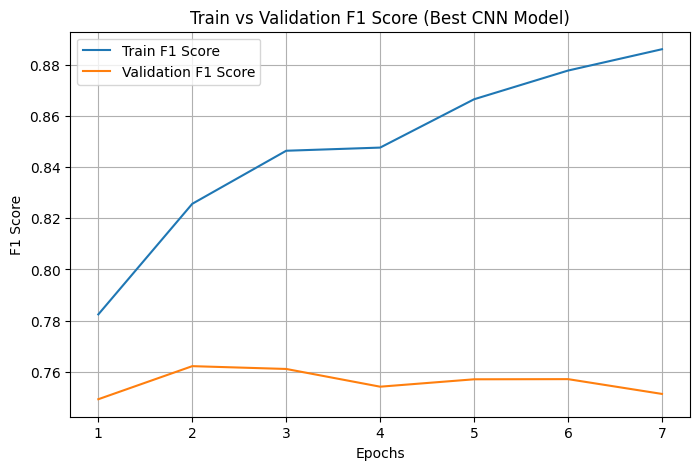

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, title_suffix=""):

    epochs = range(1, len(history['train_loss']) + 1)

    # --- Loss ---
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['dev_loss'], label='Dev Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Train vs Dev Loss {title_suffix}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Accuracy ---
    if 'train_accuracy' in history and 'val_accuracy' in history:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
        plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title(f"Train vs Validation Accuracy {title_suffix}")
        plt.legend()
        plt.grid(True)
        plt.show()

    # --- F1 Score ---
    if 'train_f1' in history and 'val_f1' in history:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history['train_f1'], label='Train F1 Score')
        plt.plot(epochs, history['val_f1'], label='Validation F1 Score')
        plt.xlabel("Epochs")
        plt.ylabel("F1 Score")
        plt.title(f"Train vs Validation F1 Score {title_suffix}")
        plt.legend()
        plt.grid(True)
        plt.show()


plot_training_history(history_cnn, title_suffix="(Best CNN Model)")

## **Comparison with other models**

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, average_precision_score

def per_class_prf(y_true, y_pred, label_order):
    P, R, F1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_order, average=None, zero_division=0
    )
    return {lbl: (float(p), float(r), float(f1)) for lbl, p, r, f1 in zip(label_order, P, R, F1)}

def per_class_prauc(y_true, proba, label_order):
    y_true = np.asarray(y_true)
    ap = {}
    for j, lbl in enumerate(label_order):
        y_bin = (y_true == lbl).astype(int)
        y_score = proba[:, j]
        ap[lbl] = float(average_precision_score(y_bin, y_score))
    return ap

def make_results_row(name, y_true, y_pred, y_proba, label_order):
    prf = per_class_prf(y_true, y_pred, label_order)
    ap  = per_class_prauc(y_true, y_proba, label_order)

    row = {"Model": name}
    per_class_vals = []
    for lbl in label_order:
        P, R, F1 = prf[lbl]
        A = ap[lbl]
        row[f"P({lbl})"]      = P
        row[f"R({lbl})"]      = R
        row[f"F1({lbl})"]     = F1
        row[f"PR-AUC({lbl})"] = A
        per_class_vals.append((P, R, F1, A))

    macro = np.mean(per_class_vals, axis=0)
    row["Macro-P"]      = float(macro[0])
    row["Macro-R"]      = float(macro[1])
    row["Macro-F1"]     = float(macro[2])
    row["Macro-PR-AUC"] = float(macro[3])
    return row


In [ ]:
# Recreate RNN model
model = BiLSTMWithAttention(
    embedding_matrix=embedding_matrix,
    pad_idx=str2idx["<pad>"],
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    attn_hidden_dim=None,
    fine_tune_embeddings=True,
    emb_dropout=0.2,
    num_classes=2,
    bidirectional=True
)

print(model)

# Train best model from the Hyperparameter Tuning
best_model_rnn, history_rnn, best_dev_f1_rnn, best_epoch = run_training(
        model,
        train_loader,
        dev_loader,
        [0, 1],
        lr=0.01,
        epochs=10,
        patience=5
)


BiLSTMWithAttention(
  (embedding): Embedding(39443, 100, padding_idx=0)
  (emb_dropout): Dropout(p=0.2, inplace=False)
  (rnn): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attention): SelfAttention(
    (w): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


Epoch 01 | TrainLoss=0.5141 DevLoss=0.4893 | TrainF1=0.8092 DevF1=0.7696 | Time=12.0s
  -> New best model found!


Epoch 02 | TrainLoss=0.4475 DevLoss=0.4747 | TrainF1=0.8415 DevF1=0.7714 | Time=11.7s
  -> New best model found!


Epoch 03 | TrainLoss=0.3962 DevLoss=0.4860 | TrainF1=0.8729 DevF1=0.7730 | Time=11.7s
  -> New best model found!


Epoch 04 | TrainLoss=0.3461 DevLoss=0.5071 | TrainF1=0.8931 DevF1=0.7643 | Time=12.0s


Epoch 05 | TrainLoss=0.3007 DevLoss=0.5261 | TrainF1=0.9029 DevF1=0.7591 | Time=11.9s


Epoch 06 | TrainLoss=0.2763 DevLoss=0.6481 | TrainF1=0.9071 DevF1=0.7573 | Time=11.7s


Epoch 07 | TrainLoss=0.2574 DevLoss=0.6392 | TrainF1=0.9181 DevF1=0.7448 | Time=11.7s


Epoch 08 | TrainLoss=0.2456 DevLoss=0.6888 | TrainF1=0.9228 DevF1=0.7373 | Time=11.5s
Early stopping after 5 epochs without improvement.


In [ ]:
# 1) Majority baseline
baseline = baseline      # already fitted earlier, or refit

# 2) Best LR from exercise 2
best_lr = lr_tfidf       # treat this as "TF-IDF+LR"

# 3) MLP wrapper so we can call predict / predict_proba
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model.eval().to("cpu")

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            preds = torch.argmax(logits, dim=1).numpy()
        return preds

    def predict_proba(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            probs = torch.softmax(logits, dim=1).numpy()
        return probs

mlp_clf = MLPWrapper(best_model_mlp)

In [ ]:

class BiLSTMWrapper:
    """
    Wrapper for BiLSTM + self-attention to behave like a sklearn classifier.
    Uses the same Dataset + DataLoader pipeline as training.
    """
    def __init__(self, model, str2idx, batch_size=BATCH_SIZE, device="cpu"):
        self.model = model.to(device).eval()
        self.str2idx = str2idx
        self.batch_size = batch_size
        self.device = device

    def _make_loader(self, X, y=None):
        # if labels not provided, use dummy zeros
        labels = y if y is not None else [0] * len(X)
        dataset = TweetsSeqDataset(X, labels, self.str2idx)
        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=collate_batch_pad
        )
        return loader

    def _predict_logits(self, X, y=None):
        loader = self._make_loader(X, y)
        all_logits = []
        self.model.eval()
        with torch.no_grad():
            for tokens, lengths, _ in loader:
                tokens = tokens.to(self.device)
                lengths = lengths.to(self.device)
                logits, _ = self.model(tokens, lengths)
                all_logits.append(logits.cpu())
        return torch.cat(all_logits, dim=0)

    def predict(self, X):
        logits = self._predict_logits(X)
        return torch.argmax(logits, dim=1).numpy()

    def predict_proba(self, X):
        logits = self._predict_logits(X)
        return torch.softmax(logits, dim=1).numpy()


rnn_clf = BiLSTMWrapper(best_model_rnn, str2idx, batch_size=BATCH_SIZE, device=device)

In [ ]:
class CNNWrapper:
    def __init__(self, model, str2idx, batch_size=BATCH_SIZE, device=device):
        self.model = model.to(device).eval()
        self.str2idx = str2idx
        self.batch_size = batch_size
        self.device = device

    def _make_loader(self, X, y=None):
        labels = y if y is not None else [0]*len(X)
        dataset = TweetsSeqDataset(X, labels, self.str2idx)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=False, collate_fn=collate_batch_pad)
        return loader

    def _predict_logits(self, X, y=None):
        loader = self._make_loader(X, y)
        all_logits = []
        with torch.no_grad():
            for tokens, lengths, _ in loader:
                tokens = tokens.to(self.device)
                lengths = lengths.to(self.device)
                logits, _ = self.model(tokens, lengths)
                all_logits.append(logits.cpu())
        return torch.cat(all_logits, dim=0)

    def predict(self, X):
        logits = self._predict_logits(X)
        return torch.argmax(logits, dim=1).numpy()

    def predict_proba(self, X):
        logits = self._predict_logits(X)
        return torch.softmax(logits, dim=1).numpy()


cnn_clf = CNNWrapper(trained_model_cnn, str2idx, batch_size=BATCH_SIZE, device=device)

In [ ]:
import gc

label_order = [0, 1]  # Negative, Positive

train_rows = []
dev_rows = []
test_rows = []

# Baseline
baseline.fit(x_train, y_train)  # baseline works on raw text, ok
y_train_pred_b = baseline.predict(x_train)
y_dev_pred_b   = baseline.predict(x_dev)
y_test_pred_b  = baseline.predict(x_test)

y_train_proba_b = baseline.predict_proba(x_train)
y_dev_proba_b   = baseline.predict_proba(x_dev)
y_test_proba_b  = baseline.predict_proba(x_test)

train_rows.append(make_results_row("Baseline", y_train, y_train_pred_b, y_train_proba_b, label_order))
dev_rows.append(make_results_row("Baseline",   y_dev,   y_dev_pred_b,   y_dev_proba_b,   label_order))
test_rows.append(make_results_row("Baseline",  y_test,  y_test_pred_b,  y_test_proba_b,  label_order))

del y_train_pred_b, y_dev_pred_b, y_test_pred_b
del y_train_proba_b, y_dev_proba_b, y_test_proba_b
gc.collect()

## TF-IDF + LR (best from assg 2)
best_lr.fit(x_train, y_train)
y_train_pred_lr = best_lr.predict(x_train)
y_dev_pred_lr   = best_lr.predict(x_dev)
y_test_pred_lr  = best_lr.predict(x_test)

y_train_proba_lr = best_lr.predict_proba(x_train)
y_dev_proba_lr   = best_lr.predict_proba(x_dev)
y_test_proba_lr  = best_lr.predict_proba(x_test)

train_rows.append(make_results_row("TF-IDF+LR", y_train, y_train_pred_lr, y_train_proba_lr, label_order))
dev_rows.append(make_results_row("TF-IDF+LR",   y_dev,   y_dev_pred_lr,   y_dev_proba_lr,   label_order))
test_rows.append(make_results_row("TF-IDF+LR",  y_test,  y_test_pred_lr,  y_test_proba_lr,  label_order))

del y_train_pred_lr, y_dev_pred_lr, y_test_pred_lr
del y_train_proba_lr, y_dev_proba_lr, y_test_proba_lr
gc.collect()

## MLP (on SVD features)
y_train_pred_m = mlp_clf.predict(X_train_svd)
y_dev_pred_m   = mlp_clf.predict(X_dev_svd)
y_test_pred_m  = mlp_clf.predict(X_test_svd)

y_train_proba_m = mlp_clf.predict_proba(X_train_svd)
y_dev_proba_m   = mlp_clf.predict_proba(X_dev_svd)
y_test_proba_m  = mlp_clf.predict_proba(X_test_svd)

train_rows.append(make_results_row("MLP", y_train, y_train_pred_m, y_train_proba_m, label_order))
dev_rows.append(make_results_row("MLP",   y_dev,   y_dev_pred_m,   y_dev_proba_m,   label_order))
test_rows.append(make_results_row("MLP",  y_test,  y_test_pred_m,  y_test_proba_m,  label_order))

del X_train_svd, X_dev_svd, X_test_svd
del y_train_pred_m, y_dev_pred_m, y_test_pred_m
del y_train_proba_m, y_dev_proba_m, y_test_proba_m
del mlp_clf
del best_model_mlp
gc.collect()

# RNN

y_train_pred_rnn = rnn_clf.predict(train_clean_x)
y_dev_pred_rnn   = rnn_clf.predict(dev_clean_x)
y_test_pred_rnn  = rnn_clf.predict(test_clean_x)

y_train_proba_rnn = rnn_clf.predict_proba(train_clean_x)
y_dev_proba_rnn   = rnn_clf.predict_proba(dev_clean_x)
y_test_proba_rnn  = rnn_clf.predict_proba(test_clean_x)

train_rows.append(make_results_row("BiLSTM", train_clean_y, y_train_pred_rnn, y_train_proba_rnn, label_order))
dev_rows.append(make_results_row("BiLSTM",   dev_clean_y,   y_dev_pred_rnn,   y_dev_proba_rnn,   label_order))
test_rows.append(make_results_row("BiLSTM",  test_clean_y,  y_test_pred_rnn,  y_test_proba_rnn,  label_order))

del y_train_pred_rnn, y_dev_pred_rnn, y_test_pred_rnn
del y_train_proba_rnn, y_dev_proba_rnn, y_test_proba_rnn
del rnn_clf
del best_model_rnn

# CNN

y_train_pred_cnn = cnn_clf.predict(train_clean_x)
y_dev_pred_cnn   = cnn_clf.predict(dev_clean_x)
y_test_pred_cnn  = cnn_clf.predict(test_clean_x)

y_train_proba_cnn = cnn_clf.predict_proba(train_clean_x)
y_dev_proba_cnn   = cnn_clf.predict_proba(dev_clean_x)
y_test_proba_cnn  = cnn_clf.predict_proba(test_clean_x)

train_rows.append(make_results_row("CNN", train_clean_y, y_train_pred_cnn, y_train_proba_cnn, label_order))
dev_rows.append(make_results_row("CNN",   dev_clean_y,   y_dev_pred_cnn,   y_dev_proba_cnn,   label_order))
test_rows.append(make_results_row("CNN",  test_clean_y,  y_test_pred_cnn,  y_test_proba_cnn,  label_order))

#################################################

cols = ["Model"]
for lbl in label_order:
    cols += [f"P({lbl})", f"R({lbl})", f"F1({lbl})", f"PR-AUC({lbl})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

print("=== TRAIN RESULTS ===")
display(train_df)
print("\n=== DEV RESULTS ===")
display(dev_df)
print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435364,0.564636,1.000000,0.721747,0.564636,0.282318,0.500000,0.360874,0.500000
1,TF-IDF+LR,0.800657,0.831846,0.815953,0.884331,0.866329,0.840309,0.853121,0.934591,0.833493,0.836077,0.834537,0.909461
2,MLP,0.825968,0.690601,0.752243,0.860903,0.788201,0.887804,0.835043,0.906844,0.807084,0.789202,0.793643,0.883873
3,BiLSTM,0.862645,0.848633,0.855582,0.927062,0.884741,0.895821,0.890247,0.958453,0.873693,0.872227,0.872914,0.942757
4,CNN,0.787948,0.826787,0.806901,0.879636,0.861179,0.828452,0.844499,0.930167,0.824564,0.827620,0.825700,0.904902



=== DEV RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435391,0.564609,1.000000,0.721725,0.564609,0.282304,0.500000,0.360863,0.500000
1,TF-IDF+LR,0.735910,0.763859,0.749624,0.814233,0.812409,0.788616,0.800336,0.881390,0.774160,0.776238,0.774980,0.847811
2,MLP,0.707028,0.594640,0.645982,0.739800,0.721544,0.809991,0.763214,0.822055,0.714286,0.702315,0.704598,0.780927
3,BiLSTM,0.753706,0.727161,0.740196,0.818993,0.795055,0.816661,0.805713,0.884793,0.774381,0.771911,0.772954,0.851893
4,CNN,0.719783,0.753768,0.736383,0.803364,0.802833,0.773585,0.787937,0.874687,0.761308,0.763676,0.762160,0.839025



=== TEST RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435362,0.564638,1.000000,0.721749,0.564638,0.282319,0.500000,0.360874,0.500000
1,TF-IDF+LR,0.731323,0.754058,0.742517,0.817475,0.805710,0.786397,0.795937,0.880550,0.768517,0.770228,0.769227,0.849012
2,MLP,0.707851,0.589587,0.643329,0.746715,0.719665,0.812375,0.763215,0.821697,0.713758,0.700981,0.703272,0.784206
3,BiLSTM,0.756770,0.718442,0.737108,0.823212,0.791329,0.822191,0.806465,0.882967,0.774050,0.770316,0.771786,0.853089
4,CNN,0.720749,0.740610,0.730544,0.805953,0.795931,0.779042,0.787396,0.872773,0.758340,0.759826,0.758970,0.839363


## **Building a character-aware CNN**



In [ ]:
from collections import Counter

CHAR_PAD = "<CPAD>"
CHAR_UNK = "<CUNK>"

def build_char_vocab(train_tokens):
    counter = Counter()
    for sent in train_tokens:   # list of token lists
        for w in sent:
            counter.update(list(w))

    idx2char = [CHAR_PAD, CHAR_UNK]
    char2idx = {CHAR_PAD: 0, CHAR_UNK: 1}

    for ch, _ in counter.most_common():
        if ch not in char2idx:
            char2idx[ch] = len(idx2char)
            idx2char.append(ch)

    return char2idx, idx2char

char2idx, idx2char = build_char_vocab(tokenized_train)
char_pad_idx = char2idx[CHAR_PAD]

print("Char vocab size:", len(char2idx))
print(idx2char[:40])

Char vocab size: 148
['<CPAD>', '<CUNK>', 'e', 'o', 't', 'a', 'n', 'h', 'i', 'l', 'r', 's', 'u', 'y', 'd', 'b', 'w', '.', 'm', 'c', 'g', 'f', 'p', 'I', 'k', '!', 'v', ',', '?', 'j', 'x', '-', "'", 'z', '*', '2', '0', ':', '1', ')']


In [ ]:
import numpy as np

# random initialization, Character embeddings are task-specific
def create_char_embedding_matrix(char2idx, char_emb_dim=50, seed=2025):
    np.random.seed(seed)
    vocab_size = len(char2idx)

    # random initialization (small values)
    char_embedding_matrix = np.random.uniform(
        low=-0.05,
        high=0.05,
        size=(vocab_size, char_emb_dim)
    ).astype(np.float32)

    # zero out padding embedding
    char_embedding_matrix[char2idx[CHAR_PAD]] = np.zeros(char_emb_dim)

    return char_embedding_matrix

char_embedding_matrix = create_char_embedding_matrix(char2idx)

In [ ]:
class TweetsCharDataset(Dataset):
    """
    Returns:
      word_ids: LongTensor [T]
      char_ids: list of LongTensors (each word has its own char sequence)
      label:    Long
    """
    def __init__(self, texts, labels, word2idx, char2idx):
        self.texts  = texts
        self.labels = np.array(labels)
        self.word2idx = word2idx
        self.char2idx = char2idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.texts[idx].split()
        word_ids = [self.word2idx.get(t, self.word2idx["<unk>"]) for t in tokens]

        # char sequences
        char_seqs = []
        for w in tokens:
            ch_ids = [self.char2idx.get(ch, self.char2idx[CHAR_UNK]) for ch in w]
            if len(ch_ids) == 0:
                ch_ids = [self.char2idx[CHAR_PAD]]
            char_seqs.append(torch.tensor(ch_ids, dtype=torch.long))

        label = self.labels[idx]

        return torch.tensor(word_ids, dtype=torch.long), char_seqs, torch.tensor(label, dtype=torch.long)

In [ ]:
def collate_batch_pad_chars(batch):
    """
    batch: list of (word_ids, char_seqs, label)
    Produces:
      X_words: [B, T]
      X_chars: [B, T, W]
      labels:  [B]
      lengths: [B]
    """
    word_seqs, char_lists, labels = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in word_seqs], dtype=torch.long)
    max_len = lengths.max().item()
    batch_size = len(word_seqs)

    # pad word sequences
    X_words = torch.full((batch_size, max_len), str2idx["<pad>"], dtype=torch.long)

    # compute max word length
    max_word_len = max(len(ch) for sent in char_lists for ch in sent)

    # init char tensor
    X_chars = torch.full(
        (batch_size, max_len, max_word_len),
        char_pad_idx,
        dtype=torch.long
    )

    labels = torch.stack(labels)

    # fill everything
    for i, (w_seq, chars) in enumerate(zip(word_seqs, char_lists)):
        L = len(w_seq)
        X_words[i, :L] = w_seq
        for j, ch_seq in enumerate(chars):
            X_chars[i, j, :len(ch_seq)] = ch_seq

    return X_words, X_chars, labels


In [ ]:
train_char_ds = TweetsCharDataset(train_clean_x, train_clean_y, str2idx, char2idx)
dev_char_ds   = TweetsCharDataset(dev_clean_x,   dev_clean_y,   str2idx, char2idx)
test_char_ds  = TweetsCharDataset(test_clean_x,  test_clean_y,  str2idx, char2idx)

train_char_loader = DataLoader(train_char_ds, batch_size=BATCH_SIZE,
                               shuffle=True, collate_fn=collate_batch_pad_chars)

dev_char_loader = DataLoader(dev_char_ds, batch_size=BATCH_SIZE,
                             shuffle=False, collate_fn=collate_batch_pad_chars)

test_char_loader = DataLoader(test_char_ds, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_batch_pad_chars)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


# Char -> word encoder (Char-CNN per word)
class CharCNNWordEncoder(nn.Module):
    """
    Turn per-word character sequences [B, T, W] into per-word char vectors [B, T, char_rep_dim].
    Uses multiple 1D conv filters over the character dimension + global max-pool.
    """
    def __init__(self, char_embedding_matrix, char_pad_idx,
                 char_emb_dim=50, char_kernel_sizes=(3,4,5), char_num_filters=50,
                 fine_tune_char_emb=True):
        super().__init__()
        # load embedding matrix if provided (numpy)
        if char_embedding_matrix is None:
            raise ValueError("Please provide char_embedding_matrix (numpy array)")
        char_embedding_matrix = torch.tensor(char_embedding_matrix, dtype=torch.float32)
        vocab_c, emb_c = char_embedding_matrix.shape
        assert emb_c == char_emb_dim, "char_emb_dim mismatch"

        self.char_emb = nn.Embedding(num_embeddings=vocab_c,
                                     embedding_dim=char_emb_dim,
                                     padding_idx=char_pad_idx)
        self.char_emb.weight.data.copy_(char_embedding_matrix)
        self.char_emb.weight.requires_grad = fine_tune_char_emb

        # convs: expect input shape (B*T, char_emb_dim, W)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=char_emb_dim,
                      out_channels=char_num_filters,
                      kernel_size=k)
            for k in char_kernel_sizes
        ])
        self.kernel_sizes = tuple(char_kernel_sizes)
        self.num_filters = char_num_filters
        self.char_rep_dim = char_num_filters * len(self.kernel_sizes)

    def forward(self, x_chars):
        """
        x_chars: LongTensor [B, T, W] (char ids, padded)
        returns: char_rep [B, T, char_rep_dim]
        """
        B, T, W = x_chars.size()
        # flatten batch+tokens -> treat each word as batch element for char-CNN
        flat = x_chars.view(B * T, W)                     # [B*T, W]
        emb = self.char_emb(flat)                         # [B*T, W, char_emb_dim]
        emb = emb.transpose(1, 2)                         # [B*T, char_emb_dim, W]

        conv_outputs = []
        for conv in self.convs:
            c = conv(emb)                                 # [B*T, num_filters, W-k+1]
            c = F.relu(c)
            # global max pool over time dim
            c, _ = torch.max(c, dim=2)                    # [B*T, num_filters]
            conv_outputs.append(c)

        char_rep = torch.cat(conv_outputs, dim=1)         # [B*T, char_rep_dim]
        char_rep = char_rep.view(B, T, -1)                # [B, T, char_rep_dim]
        return char_rep

In [ ]:
# Sentence-level CNN over concatenated word vectors
class SentenceCNNClassifier(nn.Module):
    """
    Sentence classifier:
      - pretrained word embedding matrix (loaded)
      - optional CharCNNWordEncoder producing per-word char vectors
      - concatenate word_emb + char_rep -> per-word vectors
      - apply convs over time (kernel sizes), ReLU, global max-pool
      - concat pooled features -> MLP classifier
    """
    def __init__(self, embedding_matrix, pad_idx,
                 char_encoder: CharCNNWordEncoder = None,
                 emb_dropout=0.2,
                 word_fine_tune=True,
                 kernel_sizes=(3,4,5),
                 num_filters=200,
                 hidden_dropout=0.3,
                 hidden_proj_dim=None,
                 num_classes=2):
        super().__init__()

        # word embeddings
        emb_weights = torch.tensor(embedding_matrix, dtype=torch.float32)
        vocab_size, emb_dim = emb_weights.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(emb_weights)
        self.embedding.weight.requires_grad = word_fine_tune

        self.emb_dropout = nn.Dropout(emb_dropout)

        # char encoder (optional)
        self.char_encoder = char_encoder
        self.pad_idx = pad_idx

        # resulting per-word dimension
        self.word_vec_dim = emb_dim + (char_encoder.char_rep_dim if char_encoder is not None else 0)

        # CNN convs: convs over time on channels = word_vec_dim
        # conv1d expects (B, C_in, T) so we'll transpose appropriately
        self.kernel_sizes = tuple(kernel_sizes)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=self.word_vec_dim,
                      out_channels=num_filters,
                      kernel_size=k)
            for k in self.kernel_sizes
        ])
        self.num_filters = num_filters

        # classifier head
        pooled_dim = num_filters * len(self.kernel_sizes)
        proj_dim = hidden_proj_dim if hidden_proj_dim is not None else max(pooled_dim // 2, 128)
        self.classifier = nn.Sequential(
            nn.Linear(pooled_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(hidden_dropout),
            nn.Linear(proj_dim, num_classes)
        )

    def forward(self, tokens, x_chars=None):
        """
        tokens: (B, T) LongTensor
        x_chars: (B, T, W) LongTensor or None
        returns logits: (B, num_classes)
        """
        mask = (tokens != self.pad_idx).long().to(tokens.device)   # (B, T)
        emb = self.embedding(tokens)                                # (B, T, E)
        emb = self.emb_dropout(emb)

        if self.char_encoder is not None and x_chars is not None:
            char_rep = self.char_encoder(x_chars)                  # (B, T, char_rep_dim)
            word_rep = torch.cat([emb, char_rep], dim=-1)         # (B, T, E + char_rep)
        else:
            word_rep = emb                                         # (B, T, E)

        # Prepare for conv: (B, C_in, T)
        x = word_rep.transpose(1, 2)                                # (B, C, T)

        # mask padded positions by setting very small values before pooling
        # note: convs produce outputs length <= T depending on kernel, to keep things simple
        # we will apply conv then global max over time - padded values should be ignored by mask.
        conv_pooled = []
        for conv in self.convs:
            c = conv(x)                    # (B, F, T - k + 1)
            c = F.relu(c)
            # global max over time dimension
            c, _ = torch.max(c, dim=2)     # (B, F)
            conv_pooled.append(c)

        cat = torch.cat(conv_pooled, dim=1) # (B, F * len(kernels))
        logits = self.classifier(cat)       # (B, num_classes)
        return logits



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
CHAR_EMB_DIM = char_embedding_matrix.shape[1]   # 50
CHAR_KERNEL_SIZES = (3,4,5)
CHAR_NUM_FILTERS = 30
KERNEL_SIZES = (3,4,5)
NUM_FILTERS = 200

pad_idx = str2idx["<pad>"]

# build char encoder
char_encoder = CharCNNWordEncoder(
    char_embedding_matrix=char_embedding_matrix,
    char_pad_idx=char_pad_idx,
    char_emb_dim=CHAR_EMB_DIM,
    char_kernel_sizes=CHAR_KERNEL_SIZES,
    char_num_filters=CHAR_NUM_FILTERS,
    fine_tune_char_emb=True
)

# build sentence model
model = SentenceCNNClassifier(
    embedding_matrix=embedding_matrix,
    pad_idx=pad_idx,
    char_encoder=char_encoder,
    emb_dropout=0.2,
    word_fine_tune=True,
    kernel_sizes=KERNEL_SIZES,
    num_filters=NUM_FILTERS,
    hidden_dropout=0.3,
    hidden_proj_dim=256,
    num_classes=2
).to(device)

# example one-batch forward pass
batch = next(iter(train_char_loader))   # expects collate_batch_pad_chars style loader
Xw, Xc, yb = batch             # (B, T), (B, T, W), (B,), (B,)
Xw, Xc, yb = Xw.to(device), Xc.to(device), yb.to(device)
logits = model(Xw, Xc)                  # (B, 2)
probs = F.softmax(logits, dim=1)
print("logits:", logits.shape, "probs:", probs.shape)


logits: torch.Size([256, 2]) probs: torch.Size([256, 2])


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def train_one_char_cnn_config(
    config,
    train_dataset,
    dev_dataset,
    embedding_matrix,
    char_encoder,
    pad_idx,
    device,
    patience=5,
):
    batch_size = config["batch_size"]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_batch_pad_chars,  # returns (Xw, Xc, y)
    )
    dev_loader = DataLoader(
        dev_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_batch_pad_chars,
    )

    model = SentenceCNNClassifier(
        embedding_matrix=embedding_matrix,
        pad_idx=pad_idx,
        char_encoder=char_encoder,
        emb_dropout=config.get("emb_dropout", 0.2),
        kernel_sizes=config.get("kernel_sizes", (3, 4, 5)),
        num_filters=config.get("num_filters", 200),
        hidden_dropout=config.get("hidden_dropout", 0.3),
        hidden_proj_dim=config.get("hidden_proj_dim", None),
        num_classes=config["num_classes"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state = None

    for epoch in range(config["num_epochs"]):
        # ----- TRAIN -----
        model.train()
        running_train_loss = 0.0
        total_train_samples = 0

        for Xw, Xc, yb in train_loader:
            Xw = Xw.to(device)
            Xc = Xc.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(Xw, x_chars=Xc)     # [B, C]
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * yb.size(0)
            total_train_samples += yb.size(0)

        epoch_train_loss = running_train_loss / max(total_train_samples, 1)
        history["train_loss"].append(epoch_train_loss)

        # ----- DEV LOSS + PREDICTIONS -----
        model.eval()
        running_dev_loss = 0.0
        total_dev_samples = 0
        all_true, all_pred = [], []

        with torch.no_grad():
            for Xw, Xc, yb in dev_loader:
                Xw = Xw.to(device)
                Xc = Xc.to(device)
                yb = yb.to(device)

                logits = model(Xw, x_chars=Xc)   # [B, C]
                loss = criterion(logits, yb)

                running_dev_loss += loss.item() * yb.size(0)
                total_dev_samples += yb.size(0)

                preds = torch.argmax(logits, dim=1)
                all_true.append(yb.cpu())
                all_pred.append(preds.cpu())

        epoch_dev_loss = running_dev_loss / max(total_dev_samples, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ----- DEV MACRO-F1 -----
        y_true = torch.cat(all_true).numpy()
        y_pred = torch.cat(all_pred).numpy()


        _, _, macro_f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {macro_f1:.4f}"
        )

        # ----- BEST CHECKPOINT -----
        if macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # ----- EARLY STOPPING -----
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return model, history, best_dev_macro_f1


In [ ]:
def predict_with_proba_cnn(model, loader, device):
    model.eval()
    all_true, all_pred, all_proba = [], [], []

    with torch.no_grad():
        for Xw, Xc, yb, _ in loader:
            Xw = Xw.to(device)
            Xc = Xc.to(device)
            yb = yb.to(device)

            logits = model(Xw, x_chars=Xc)   # (B, C)
            proba = F.softmax(logits, dim=-1)

            preds = torch.argmax(proba, dim=1)

            all_true.append(yb.cpu().numpy())
            all_pred.append(preds.cpu().numpy())
            all_proba.append(proba.cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.vstack(all_proba)

    return y_true, y_pred, y_proba


In [ ]:
cnn_char_configs = [
    {
        "name": "CharCNN_small",
        "batch_size": 128,
        "lr": 1e-3,
        "num_epochs": 10,
        "num_classes": 2,

        # sentence-level CNN
        "kernel_sizes": (3, 4, 5),
        "num_filters": 150,

        # classifier head
        "hidden_proj_dim": 256,
        "hidden_dropout": 0.4,

        # embeddings
        "emb_dropout": 0.2,
    },
    {
        "name": "CharCNN_large",
        "batch_size": 256,
        "lr": 5e-4,
        "num_epochs": 10,
        "num_classes": 2,

        # sentence-level CNN (higher capacity)
        "kernel_sizes": (2, 3, 4, 5),
        "num_filters": 250,

        # classifier head
        "hidden_proj_dim": 512,
        "hidden_dropout": 0.5,

        # embeddings
        "emb_dropout": 0.3,
    }
]


In [ ]:
best_cnn_char_model = None
best_cnn_char_config = None
best_cnn_char_macro_f1 = -1.0
best_cnn_char_history = None

for cfg in cnn_char_configs:
    print("\n===== Training CNN+char config:", cfg["name"], "=====")

    model, history, dev_macro_f1 = train_one_char_cnn_config(
        config=cfg,
        train_dataset=train_char_ds,
        dev_dataset=dev_char_ds,
        embedding_matrix=embedding_matrix,
        pad_idx=pad_idx,
        char_encoder=char_encoder,
        device=device,
        patience=5,
    )

    if dev_macro_f1 > best_cnn_char_macro_f1:
        best_cnn_char_macro_f1 = dev_macro_f1
        best_cnn_char_model = model
        best_cnn_char_config = cfg
        best_cnn_char_history = history

print("\nBest CNN+char config:", best_cnn_char_config)
print("Best Dev Macro-F1 (CNN+char):", best_cnn_char_macro_f1)



===== Training CNN+char config: CharCNN_small =====
[CharCNN_small] Epoch 1/10 | train loss: 0.5837 | dev loss: 0.5044 | dev macro-F1: 0.7466
[CharCNN_small] Epoch 2/10 | train loss: 0.4703 | dev loss: 0.5115 | dev macro-F1: 0.7407
[CharCNN_small] Epoch 3/10 | train loss: 0.4183 | dev loss: 0.5070 | dev macro-F1: 0.7462
[CharCNN_small] Epoch 4/10 | train loss: 0.3781 | dev loss: 0.5319 | dev macro-F1: 0.7432
[CharCNN_small] Epoch 5/10 | train loss: 0.3476 | dev loss: 0.5777 | dev macro-F1: 0.7351
[CharCNN_small] Epoch 6/10 | train loss: 0.3204 | dev loss: 0.5909 | dev macro-F1: 0.7301
[CharCNN_small] Epoch 7/10 | train loss: 0.3029 | dev loss: 0.6184 | dev macro-F1: 0.7330
[CharCNN_small] Epoch 8/10 | train loss: 0.2906 | dev loss: 0.6698 | dev macro-F1: 0.7349
Early stopping triggered.

===== Training CNN+char config: CharCNN_large =====
[CharCNN_large] Epoch 1/10 | train loss: 0.6403 | dev loss: 0.4995 | dev macro-F1: 0.7417
[CharCNN_large] Epoch 2/10 | train loss: 0.4571 | dev loss

## **Temporal Averaging**

In [ ]:
def train_one_cnn_with_temporal_averaging(
    config,
    train_dataset,
    dev_dataset,
    embedding_matrix,
    char_encoder,
    pad_idx,
    char_pad_idx,
    device,
    patience=5
):
    """
    Trainer for SentenceCNNClassifier with optional CharCNNWordEncoder.
    Keeps:
      - best checkpoint by dev macro-F1
      - temporal average of weights over epochs
    Returns:
      best_model, history, best_dev_macro_f1
    """
    batch_size = config["batch_size"]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_batch_pad_chars if char_encoder is not None else collate_batch_pad
    )
    dev_loader = DataLoader(
        dev_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_batch_pad_chars if char_encoder is not None else collate_batch_pad
    )

    model = SentenceCNNClassifier(
        embedding_matrix=embedding_matrix,
        pad_idx=pad_idx,
        char_encoder=char_encoder,
        emb_dropout=config.get("emb_dropout", 0.2),
        kernel_sizes=config.get("kernel_sizes", (3,4,5)),
        num_filters=config.get("num_filters", 200),
        hidden_dropout=config.get("hidden_dropout", 0.3),
        hidden_proj_dim=config.get("hidden_proj_dim", None),
        num_classes=config["num_classes"]
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None

    avg_state_dict = None
    avg_count = 0

    for epoch in range(config["num_epochs"]):
        # ----- TRAIN -----
        model.train()
        running_loss = 0.0
        total_samples = 0

        for Xw, Xc, yb in train_loader:
            Xw, Xc, yb = Xw.to(device), Xc.to(device) if Xc is not None else None, yb.to(device)
            optimizer.zero_grad()

            logits = model(Xw, x_chars=Xc)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            total_samples += yb.size(0)

        epoch_train_loss = running_loss / max(total_samples, 1)
        history["train_loss"].append(epoch_train_loss)

        # ----- DEV -----
        model.eval()
        running_dev_loss = 0.0
        total_dev_samples = 0
        all_true, all_pred = [], []

        with torch.no_grad():
            for Xw, Xc, yb in dev_loader:
                Xw, Xc, yb = Xw.to(device), Xc.to(device) if Xc is not None else None, yb.to(device)
                logits = model(Xw, x_chars=Xc)
                loss = criterion(logits, yb)

                running_dev_loss += loss.item() * yb.size(0)
                total_dev_samples += yb.size(0)

                preds = torch.argmax(logits, dim=1)
                all_true.append(yb.cpu())
                all_pred.append(preds.cpu())

        epoch_dev_loss = running_dev_loss / max(total_dev_samples, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ----- DEV MACRO-F1 -----
        y_true = torch.cat(all_true).numpy()
        y_pred = torch.cat(all_pred).numpy()
        from sklearn.metrics import f1_score
        dev_macro_f1 = f1_score(y_true, y_pred, average="macro")

        print(f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
              f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
              f"dev macro-F1: {dev_macro_f1:.4f}")

        # ----- BEST CHECKPOINT -----
        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # ----- TEMPORAL AVERAGING -----
        with torch.no_grad():
            current_state = model.state_dict()
            if avg_state_dict is None:
                avg_state_dict = {k: v.cpu().clone() for k, v in current_state.items()}
                avg_count = 1
            else:
                avg_count += 1
                for k, v in current_state.items():
                    avg_state_dict[k].mul_((avg_count - 1)/avg_count).add_(v.cpu()/avg_count)

        # ----- EARLY STOPPING -----
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i-1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping triggered.")
                break

    # ----- BUILD MODELS -----
    best_model = SentenceCNNClassifier(
        embedding_matrix=embedding_matrix,
        pad_idx=pad_idx,
        char_encoder=char_encoder,
        emb_dropout=config.get("emb_dropout", 0.2),
        kernel_sizes=config.get("kernel_sizes", (3,4,5)),
        num_filters=config.get("num_filters", 200),
        hidden_dropout=config.get("hidden_dropout", 0.3),
        hidden_proj_dim=config.get("hidden_proj_dim", None),
        num_classes=config["num_classes"]
    ).to(device).to(device)

    if best_state_dict is not None:
        best_model.load_state_dict(best_state_dict)

    avg_model = SentenceCNNClassifier(
        embedding_matrix=embedding_matrix,
        pad_idx=pad_idx,
        char_encoder=char_encoder,
        emb_dropout=config.get("emb_dropout", 0.2),
        kernel_sizes=config.get("kernel_sizes", (3,4,5)),
        num_filters=config.get("num_filters", 200),
        hidden_dropout=config.get("hidden_dropout", 0.3),
        hidden_proj_dim=config.get("hidden_proj_dim", None),
        num_classes=config["num_classes"]
    ).to(device).to(device)

    if avg_state_dict is not None:
        avg_model.load_state_dict(avg_state_dict)

    # DEV macro-F1 for averaged model
    avg_model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for Xw, Xc, yb in dev_loader:
            Xw, Xc, yb = Xw.to(device), Xc.to(device) if Xc is not None else None, yb.to(device)
            logits = avg_model(Xw, x_chars=Xc)
            preds = torch.argmax(logits, dim=1)
            all_true.append(yb.cpu())
            all_pred.append(preds.cpu())
    y_true = torch.cat(all_true).numpy()
    y_pred = torch.cat(all_pred).numpy()
    avg_dev_macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"[{config['name']}] Best dev macro-F1: {best_dev_macro_f1:.4f} | "
          f"Temporal-avg dev macro-F1: {avg_dev_macro_f1:.4f}")

    return best_model, history, best_dev_macro_f1


In [ ]:
best_cnn_ta_char_model = None
best_cnn_ta_char_config = None
best_cnn_ta_char_macro_f1 = -1.0
best_cnn_ta_char_history = None

for cfg in cnn_char_configs:
    print("\n===== Training CNN+char config:", cfg["name"], "=====")

    model, history, dev_macro_f1 = train_one_cnn_with_temporal_averaging(
        config=cfg,
        train_dataset=train_char_ds,
        dev_dataset=dev_char_ds,
        embedding_matrix=embedding_matrix,
        pad_idx=pad_idx,
        char_pad_idx=char_pad_idx,
        char_encoder=char_encoder,
        device=device,
        patience=5,
    )

    if dev_macro_f1 > best_cnn_ta_char_macro_f1:
        best_cnn_ta_char_macro_f1 = dev_macro_f1
        best_cnn_ta_char_model = model
        best_cnn_ta_char_config = cfg
        best_cnn_ta_char_history = history

print("\nBest CNN+char config:", best_cnn_char_config)
print("Best Dev Macro-F1 (CNN+char):", best_cnn_char_macro_f1)


===== Training CNN+char config: CharCNN_small =====
[CharCNN_small] Epoch 1/10 | train loss: 0.6141 | dev loss: 0.5299 | dev macro-F1: 0.7328
[CharCNN_small] Epoch 2/10 | train loss: 0.4882 | dev loss: 0.5333 | dev macro-F1: 0.7452
[CharCNN_small] Epoch 3/10 | train loss: 0.4437 | dev loss: 0.5174 | dev macro-F1: 0.7236
[CharCNN_small] Epoch 4/10 | train loss: 0.4046 | dev loss: 0.5164 | dev macro-F1: 0.7414
[CharCNN_small] Epoch 5/10 | train loss: 0.3773 | dev loss: 0.5406 | dev macro-F1: 0.7343
[CharCNN_small] Epoch 6/10 | train loss: 0.3547 | dev loss: 0.5882 | dev macro-F1: 0.7325
[CharCNN_small] Epoch 7/10 | train loss: 0.3412 | dev loss: 0.6162 | dev macro-F1: 0.7362
[CharCNN_small] Epoch 8/10 | train loss: 0.3262 | dev loss: 0.7182 | dev macro-F1: 0.7286
[CharCNN_small] Epoch 9/10 | train loss: 0.3178 | dev loss: 0.6149 | dev macro-F1: 0.7335
[CharCNN_small] Epoch 10/10 | train loss: 0.3100 | dev loss: 0.6447 | dev macro-F1: 0.7307
[CharCNN_small] Best dev macro-F1: 0.7452 | Te

## **CNN model comparison**

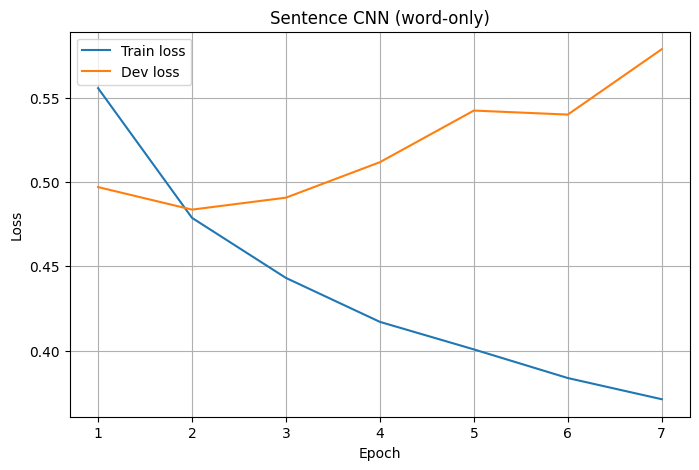

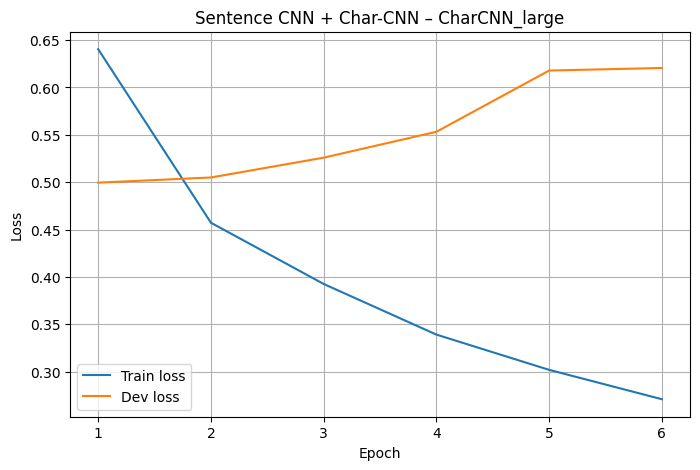

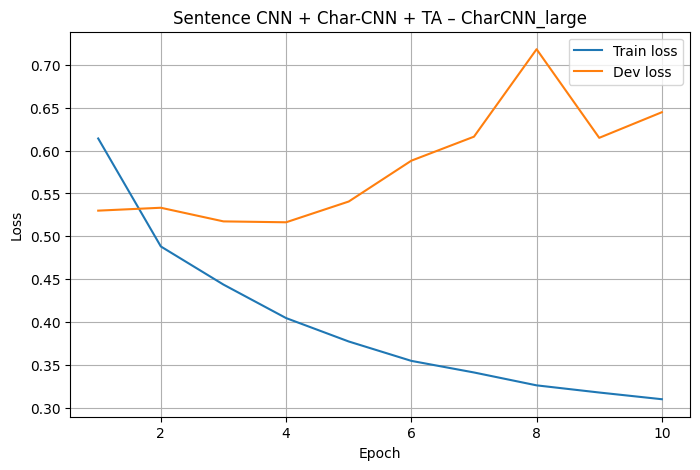

In [ ]:
# Word-only CNN
plt.figure(figsize=(8, 5))
epochs = range(1, len(history_cnn["train_loss"]) + 1)

plt.plot(epochs, history_cnn["train_loss"], label="Train loss")
plt.plot(epochs, history_cnn["dev_loss"],   label="Dev loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sentence CNN (word-only)")
plt.legend()
plt.grid(True)
plt.show()


# Char-aware CNN
plt.figure(figsize=(8, 5))
epochs = range(1, len(best_cnn_char_history["train_loss"]) + 1)

plt.plot(epochs, best_cnn_char_history["train_loss"], label="Train loss")
plt.plot(epochs, best_cnn_char_history["dev_loss"],   label="Dev loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Sentence CNN + Char-CNN – {best_cnn_char_config['name']}")
plt.legend()
plt.grid(True)
plt.show()


# Char-aware CNN with Temporal Averaging
plt.figure(figsize=(8, 5))
epochs = range(1, len(best_cnn_ta_char_history["train_loss"]) + 1)

plt.plot(epochs, best_cnn_ta_char_history["train_loss"], label="Train loss")
plt.plot(epochs, best_cnn_ta_char_history["dev_loss"],   label="Dev loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Sentence CNN + Char-CNN + TA – {best_cnn_char_config['name']}")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
class CharCNNWrapper:
    def __init__(
        self,
        model,
        word2idx,
        char2idx,
        batch_size=32,
        device="cpu"
    ):
        self.model = model.to(device).eval()
        self.word2idx = word2idx
        self.char2idx = char2idx
        self.batch_size = batch_size
        self.device = device

    def _make_loader(self, X, y=None):
        # dummy labels if none are provided
        if y is None:
            y = [0] * len(X)

        dataset = TweetsCharDataset(
            texts=X,
            labels=y,
            word2idx=self.word2idx,
            char2idx=self.char2idx
        )

        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=collate_batch_pad_chars
        )

        return loader

    def _predict_logits(self, X):
        loader = self._make_loader(X)

        all_logits = []

        with torch.no_grad():
            for Xw, Xc, _ in loader:
                Xw = Xw.to(self.device)
                Xc = Xc.to(self.device)

                logits = self.model(Xw, x_chars=Xc)
                all_logits.append(logits.cpu())

        return torch.cat(all_logits, dim=0)

    def predict(self, X):
        logits = self._predict_logits(X)
        return torch.argmax(logits, dim=1).numpy()

    def predict_proba(self, X):
        logits = self._predict_logits(X)
        return torch.softmax(logits, dim=1).numpy()


cnn_char_clf = CharCNNWrapper(
    model=best_cnn_char_model,
    word2idx=str2idx,
    char2idx=char2idx,
    batch_size=BATCH_SIZE,
    device=device
)

cnn_ta_clf = CharCNNWrapper(
    model=best_cnn_ta_char_model,
    word2idx=str2idx,
    char2idx=char2idx,
    batch_size=BATCH_SIZE,
    device=device
)

In [ ]:
import gc

label_order = [0, 1]  # Negative, Positive

train_rows = []
dev_rows   = []
test_rows  = []

# CNN (word-only)
y_train_pred_cnn = cnn_clf.predict(train_clean_x)
y_dev_pred_cnn   = cnn_clf.predict(dev_clean_x)
y_test_pred_cnn  = cnn_clf.predict(test_clean_x)

y_train_proba_cnn = cnn_clf.predict_proba(train_clean_x)
y_dev_proba_cnn   = cnn_clf.predict_proba(dev_clean_x)
y_test_proba_cnn  = cnn_clf.predict_proba(test_clean_x)

train_rows.append(make_results_row(
    "CNN", train_clean_y, y_train_pred_cnn, y_train_proba_cnn, label_order
))
dev_rows.append(make_results_row(
    "CNN", dev_clean_y, y_dev_pred_cnn, y_dev_proba_cnn, label_order
))
test_rows.append(make_results_row(
    "CNN", test_clean_y, y_test_pred_cnn, y_test_proba_cnn, label_order
))


# CNN + CHAR-CNN
y_train_pred_cnn_char = cnn_char_clf.predict(train_clean_x)
y_dev_pred_cnn_char   = cnn_char_clf.predict(dev_clean_x)
y_test_pred_cnn_char  = cnn_char_clf.predict(test_clean_x)

y_train_proba_cnn_char = cnn_char_clf.predict_proba(train_clean_x)
y_dev_proba_cnn_char   = cnn_char_clf.predict_proba(dev_clean_x)
y_test_proba_cnn_char  = cnn_char_clf.predict_proba(test_clean_x)

train_rows.append(make_results_row(
    "CNN-char", train_clean_y, y_train_pred_cnn_char, y_train_proba_cnn_char, label_order
))
dev_rows.append(make_results_row(
    "CNN-char", dev_clean_y, y_dev_pred_cnn_char, y_dev_proba_cnn_char, label_order
))
test_rows.append(make_results_row(
    "CNN-char", test_clean_y, y_test_pred_cnn_char, y_test_proba_cnn_char, label_order
))


# CNN + CHAR + TEMPORAL AVERAGING
y_train_pred_cnn_ta = cnn_ta_clf.predict(train_clean_x)
y_dev_pred_cnn_ta   = cnn_ta_clf.predict(dev_clean_x)
y_test_pred_cnn_ta  = cnn_ta_clf.predict(test_clean_x)

y_train_proba_cnn_ta = cnn_ta_clf.predict_proba(train_clean_x)
y_dev_proba_cnn_ta   = cnn_ta_clf.predict_proba(dev_clean_x)
y_test_proba_cnn_ta  = cnn_ta_clf.predict_proba(test_clean_x)

train_rows.append(make_results_row(
    "CNN-TA", train_clean_y, y_train_pred_cnn_ta, y_train_proba_cnn_ta, label_order
))
dev_rows.append(make_results_row(
    "CNN-TA", dev_clean_y, y_dev_pred_cnn_ta, y_dev_proba_cnn_ta, label_order
))
test_rows.append(make_results_row(
    "CNN-TA", test_clean_y, y_test_pred_cnn_ta, y_test_proba_cnn_ta, label_order
))


# FINAL TABLES
cols = ["Model"]
for lbl in label_order:
    cols += [f"P({lbl})", f"R({lbl})", f"F1({lbl})", f"PR-AUC({lbl})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,CNN,0.787948,0.826787,0.806901,0.879636,0.861179,0.828452,0.844499,0.930167,0.824564,0.827620,0.825700,0.904902
1,CNN-char,0.857039,0.738550,0.793395,0.894945,0.817842,0.905017,0.859224,0.936913,0.837440,0.821784,0.826310,0.915929
2,CNN-TA,0.797577,0.757002,0.776760,0.862175,0.819722,0.851873,0.835488,0.919323,0.808649,0.804438,0.806124,0.890749



=== DEV RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,CNN,0.719783,0.753768,0.736383,0.803364,0.802833,0.773585,0.787937,0.874687,0.761308,0.763676,0.762160,0.839025
1,CNN-char,0.760919,0.621655,0.684273,0.790795,0.744203,0.849294,0.793283,0.862064,0.752561,0.735474,0.738778,0.826430
2,CNN-TA,0.729698,0.677176,0.702457,0.781668,0.764025,0.806455,0.784667,0.860821,0.746862,0.741816,0.743562,0.821245



=== TEST RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,CNN,0.720749,0.740610,0.730544,0.805953,0.795931,0.779042,0.787396,0.872773,0.758340,0.759826,0.758970,0.839363
1,CNN-char,0.763133,0.623922,0.686542,0.791058,0.746076,0.850877,0.795038,0.862629,0.754605,0.737400,0.740790,0.826844
2,CNN-TA,0.728737,0.668719,0.697439,0.780500,0.760116,0.808321,0.783478,0.856789,0.744426,0.738520,0.740459,0.818645
